### Open Field Ephys QC and Summary

1) Treats "mouse_name" as MouseID and builds a per-mouse summary table with counts and mean/median metrics.
2) Displays the first 5 rows and the per-mouse summary.
3) Plots mean_firing_rate distributions by mouse (boxplot).
4) Plots spatial_info vs coherence, with points grouped and colored by mouse, and legend outside.



Load the open_field.xlsx data into a DataFrame, cache it as Parquet, reload it, and preview basic info (head/shape/columns).
Perform data quality checks on df (trim column names, missing values, duplicates, outliers, type consistency, and categorical value consistency).

"""
- Load actogram data from Excel- Convert to Parquet for faster loading
- Basic QC checks on the dataframe structure and content
  - Check for leading/trailing whitespace in column names
  - Count missing values per column
  - Count duplicate rows
  - Identify outliers in numeric columns (using IQR method)
  - Check for inconsistent data types within columns
  - List unique values in categorical columns
- Basic sanity checks on the data content
    - Distribution of mean firing rates across cells and mice
    - Relationship between spatial information and coherence
    - Per-mouse summary statistics (number of cells, mean firing rate, etc.)
- Violin plots with overlaid points (one colour per mouse, using tab20b)
    - Mean and median lines styled differently from default (e.g. mean in green, median in black)
    - Legend for mean/median line styles (not from tab20/tab20b)
    - Points use tab20b, one colour per mouse
- Statistical comparisons between experimenters (Mann–Whitney U test)
    - Only if there are exactly 2 experimenters and at least 3 samples per group
    - Annotate plots with p-values and significance stars
    - Include summary statistics (n, mean, median) in the annotation
"""


In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import re, math, textwrap
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
from pathlib import Path

# Optional: nice dataframe display in notebooks (falls back to print)
try:
    from IPython.display import display  # type: ignore
    def display_df(title, x):
        print(title)
        display(x)
except Exception:
    def display_df(title, x):
        print(title)
        print(x)

In [2]:
# Set the input path ONCE (edit this one line only)
OPEN_FIELD_XLSX_PATH = Path('/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/concatenated_trials.xlsx')
OPEN_FIELD_DIR = OPEN_FIELD_XLSX_PATH.parent
# OPEN_FIELD_OUTDIR = OPEN_FIELD_DIR.parent / "OpenField_QC_outputs"
# (or, if you want it INSIDE the same folder as the excel:)
OPEN_FIELD_OUTDIR = OPEN_FIELD_DIR / "OpenField_QC_outputs"

OPEN_FIELD_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OPEN_FIELD_OUTDIR)

df_open_field = pd.read_excel(OPEN_FIELD_XLSX_PATH) #select all cells in all trials

# Keep only openfield trials
df_open_field = df_open_field.loc[
    df_open_field["environment"].astype(str).str.contains("open.?field", case=False, na=False)
].copy()

# check if parket file exists and is up to date, otherwise save to parquet for faster loading next time

PARQUET_PATH = os.path.join(OPEN_FIELD_OUTDIR, "open_field.parquet")
df_open_field.to_parquet(PARQUET_PATH, index=False)
df_open_field = pd.read_parquet(PARQUET_PATH)

print(df_open_field["environment"].value_counts(dropna=False).head(10))
df_open_field.shape, df_open_field.columns.tolist()[:5], df_open_field.head()



Saving outputs to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs
environment
open_field    1078
Name: count, dtype: int64


((1078, 37),
 ['Unnamed: 0', 'filename', 'channel', 'cluster', 'num_spikes'],
    Unnamed: 0                                           filename  channel  \
 0           0  /home/robin/Documents/Science/SWC/jok_loukia_r...        7   
 1           1  /home/robin/Documents/Science/SWC/jok_loukia_r...        7   
 2           2  /home/robin/Documents/Science/SWC/jok_loukia_r...        7   
 3           3  /home/robin/Documents/Science/SWC/jok_loukia_r...        7   
 4           4  /home/robin/Documents/Science/SWC/jok_loukia_r...        7   
 
    cluster  num_spikes  mouse_name Experimenter  Age_weeks Genotype  \
 0       28        2438     1116810       Loukia       76.9     NLGF   
 1       27         829     1116810       Loukia       76.9     NLGF   
 2       26         618     1116810       Loukia       76.9     NLGF   
 3       25         934     1116810       Loukia       76.9     NLGF   
 4       23        1010     1116810       Loukia       76.9     NLGF   
 
    spike_width  .

In [3]:
# df_open_field = pd.read_excel(os.path.join(OPEN_FIELD_DIR, "open_field.xlsx"))

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}\nAvailable: {list(df.columns)}")

celltype_col = _find_col(df_open_field, ["cell_type", "Cell type", "Cell Type"])
genotype_col  = _find_col(df_open_field, ["Phenotype", "genotype", "Genotype", "geno", "genotype_group", "Genotype group"])
trial_col     = _find_col(df_open_field, ["trial_type", "trial", "environment"])

df_tmp = df_open_field.copy()

# clean "['openfieldb']" -> "openfieldb"
df_tmp["trial_type_clean"] = (
    df_tmp[trial_col]
    .astype(str)
    .str.replace(r"[\[\]']", "", regex=True)
    .str.strip()
)

# counts: (trial, genotype, cell_type) -> n
counts_by_trial_geno_celltype = (
    df_tmp
    .groupby(["trial_type_clean", genotype_col, celltype_col], dropna=False)
    .size()
    .rename("n")
    .reset_index()
)

# wide table: rows = (trial, genotype), columns = cell types, values = counts
table = (
    counts_by_trial_geno_celltype
    .pivot_table(
        index=["trial_type_clean", genotype_col],
        columns=celltype_col,
        values="n",
        fill_value=0,
        aggfunc="sum",
    )
    .sort_index()
)

print("Cell type counts by trial and genotype:")
display(table)

Cell type counts by trial and genotype:


Cell type                  Interneuron  Pyramidal
trial_type_clean Genotype                        
open_field       NLGF              205        316
                 WT                142        415

In [4]:
"""Basic QC checks on the dataframe structure and content
- Check for leading/trailing whitespace in column names
- Count missing values per column
- Count duplicate rows
- Identify outliers in numeric columns (using IQR method)
- Check for inconsistent data types within columns
- List unique values in categorical columns
"""

# Remove leading/trailing whitespace from column names
df_open_field.columns = df_open_field.columns.str.strip()

# Missing values per column
missing_values = df_open_field.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# Duplicate rows
duplicate_rows = df_open_field.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Outliers in numeric columns via IQR
numerical_cols = df_open_field.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    Q1 = df_open_field[col].quantile(0.25)
    Q3 = df_open_field[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_open_field[(df_open_field[col] < lower_bound) | (df_open_field[col] > upper_bound)]
    print(f"Column: {col}, Number of outliers: {len(outliers)}")

# Inconsistent types per column (can be slow on very large dataframes)
for col in df_open_field.columns:
    data_types = df_open_field[col].apply(type).value_counts()
    print(f"Column: {col}, Data types:\n{data_types}\n")

# Unique values in categorical columns
categorical_cols = df_open_field.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    unique_values = df_open_field[col].unique()
    print(f"Column: {col}, Unique values:\n{unique_values}\n")

Missing values in each column:
Unnamed: 0                          0
filename                            0
channel                             0
cluster                             0
num_spikes                          0
mouse_name                          0
Experimenter                        0
Age_weeks                           0
Genotype                            0
spike_width                         0
Cell type                           0
theta_mod_v1                        0
theta_mod_v2                       20
theta_mod_v3                        0
peak_rate                           0
mean_rate                           0
ahp_decay                         130
field_size                          0
phase_mean                          0
phase_variance                      0
overdispersion                      0
spatial_info                        0
coherence                           0
phase_locking_vector_length         0
phase_locking_z_stat                0
phase_locking_pval 

Per-mouse summary


,mouse_name,n_cells,n_tetrodes,mean_mean_firing_rate,median_mean_firing_rate,mean_spatial_info,mean_coherence,mean_field_size,mean_theta_modulation
14,1118467,140,8,1.545198,0.831377,0.274678,0.470469,673.601565,0.060847
8,1116808,111,8,1.254848,0.398834,0.169066,0.284318,730.082118,0.053400
9,1116810,94,7,0.803524,0.361782,0.129756,0.118140,764.981813,0.016719
13,1118466,83,8,2.571402,1.015730,0.323800,0.425916,682.034904,0.046059
15,1118468,68,8,1.888974,0.676726,0.600753,0.512061,550.592354,0.096879
6,733075,66,8,3.276084,0.674797,0.107286,0.096208,645.222303,0.019123
16,1118674,66,7,1.820311,0.695396,0.584979,0.337976,558.639921,0.086773
7,1116806,57,8,1.977855,0.583680,0.238503,0.435728,701.021115,0.047536
4,726050,57,8,1.407598,0.786696,0.170976,0.181126,625.320152,0.024675
12,1117537,51,6,1.836533,0.726196,0.500911,0.364473,652.985294,0.074833


Summary saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/1.open_field_summary.csv
-----------------------------------------------------------------------------------------------------------------------------------------------
Open field data (first 100 rows)


,Unnamed: 0,filename,channel,cluster,num_spikes,mouse_name,Experimenter,Age_weeks,Genotype,spike_width,...,head_dir_mean_resultant_angle,contamination_Q,contamination_R,head_dir_kl_div,kl_spatial_sparsity,spatial_sparsity,environment,half_split_stability,odd_even_stability,theta_phase_label
0,0,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,28,2438,1116810,Loukia,76.9,NLGF,489.795918,...,2.881674,0.11976,0.000064,0.017561,0.533207,0.961626,open_field,0.611469,0.720919,Peak
1,1,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,27,829,1116810,Loukia,76.9,NLGF,142.857143,...,3.236768,0.00000,0.127398,0.020096,0.533207,0.983011,open_field,0.299243,0.527620,Middle
2,2,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,26,618,1116810,Loukia,76.9,NLGF,346.938776,...,0.878663,0.00000,0.139625,0.033001,0.533207,0.971124,open_field,0.357244,0.591473,Middle
3,3,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,25,934,1116810,Loukia,76.9,NLGF,489.795918,...,3.308153,0.00000,0.124848,0.020773,0.533207,0.924774,open_field,0.465514,0.846983,Middle
4,4,/home/robin/Documents/Science/SWC/jok_loukia_r...,7,23,1010,1116810,Loukia,76.9,NLGF,285.714286,...,1.721044,0.00000,0.004622,0.032574,0.533207,0.917997,open_field,0.166132,0.760536,Middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,122,/home/robin/Documents/Science/SWC/jok_loukia_r...,2,23,861,1118466,Loukia,71.3,WT,142.857143,...,4.924659,0.00000,0.101740,0.031898,0.429713,0.970465,open_field,0.575084,0.686360,Middle
96,123,/home/robin/Documents/Science/SWC/jok_loukia_r...,3,20,110,1118466,Loukia,71.3,WT,224.489796,...,1.529551,0.00000,0.424906,0.181240,0.429713,0.912993,open_field,0.128547,0.183228,Middle
97,124,/home/robin/Documents/Science/SWC/jok_loukia_r...,2,20,212,1118466,Loukia,71.3,WT,183.673469,...,3.450973,0.00000,0.251167,0.092095,0.429713,0.914846,open_field,0.353546,0.385309,Middle
98,125,/home/robin/Documents/Science/SWC/jok_loukia_r...,2,19,218,1118466,Loukia,71.3,WT,183.673469,...,6.087149,0.00000,0.284992,0.102894,0.429713,0.936677,open_field,0.222500,0.344825,Middle


<Figure size 640x480 with 0 Axes>

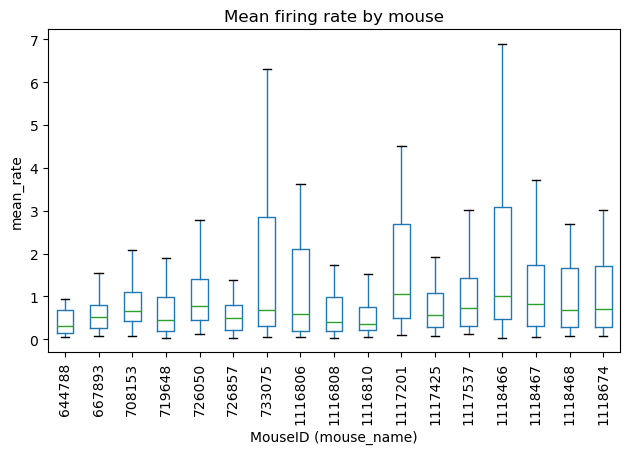

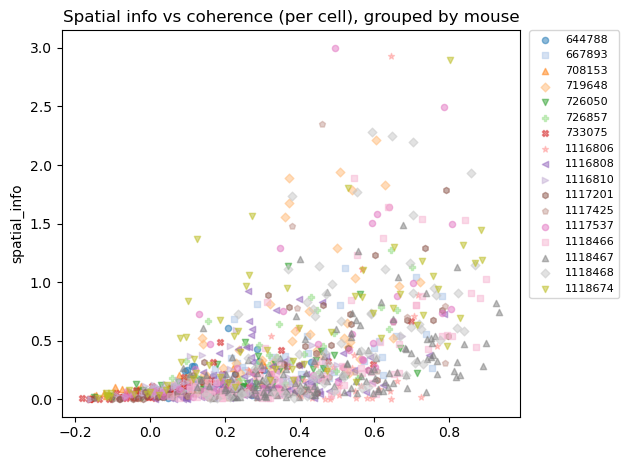

In [5]:
"""Basic sanity checks on the data content
- Distribution of mean firing rates across cells and mice
- Relationship between spatial information and coherence
- Per-mouse summary statistics (number of cells, mean firing rate, etc.)
"""

# Treat mouse_name as MouseID
mouse_col = "mouse_name"
mice = sorted(df_open_field[mouse_col].dropna().unique().tolist())

# Per-mouse summary
summary = (df_open_field.groupby(mouse_col)
             .agg(
                 n_cells=("cluster","count"),
                 n_tetrodes=("channel","nunique"),
                 mean_mean_firing_rate=("mean_rate","mean"),
                 median_mean_firing_rate=("mean_rate","median"),
                 mean_spatial_info=("spatial_info","mean"),
                 mean_coherence=("coherence","mean"),
                 mean_field_size=("field_size","mean"),
                 mean_theta_modulation=("theta_mod_v3","mean"),
             )
             .reset_index()
             .sort_values("n_cells", ascending=False))

display_df("Per-mouse summary", summary)
save_path = os.path.join(OPEN_FIELD_OUTDIR, "1.open_field_summary.csv")
summary.to_csv(save_path, index=False)
print(f"Summary saved to: {save_path}")
print("-----------------------------------------------------------------------------------------------------------------------------------------------")                    
display_df("Open field data (first 100 rows)", df_open_field.head(100))


# Plot 1: distribution of mean firing rate per mouse
plt.figure()
df_open_field.boxplot(column="mean_rate", by=mouse_col, grid=False, rot=90, showfliers=False)
plt.title("Mean firing rate by mouse")
plt.suptitle("")
plt.xlabel("MouseID (mouse_name)")
plt.ylabel("mean_rate")
plt.tight_layout()
plt.savefig(os.path.join(OPEN_FIELD_OUTDIR, "1.mean_firing_rate_boxplot_by_mouse.png"), dpi=300, bbox_inches="tight")   
plt.show()

# Plot 2: spatial_info vs coherence (per cell), grouped by mouse with color + marker
plt.figure()

markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "p"]
cmap = plt.get_cmap("tab20")  # 20 distinct colors, then repeats

for i, m in enumerate(mice):
    g = df_open_field.loc[df_open_field[mouse_col] == m]
    plt.scatter(
        g["coherence"],
        g["spatial_info"],
        label=str(m),
        alpha=0.5,
        s=20,
        marker=markers[i % len(markers)],
        color=cmap(i % 20),
    )

plt.title("Spatial info vs coherence (per cell), grouped by mouse")
plt.xlabel("coherence")
plt.ylabel("spatial_info")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OPEN_FIELD_OUTDIR, "1.spatial_info_vs_coherence_by_mouse.png"), dpi=300, bbox_inches="tight")
plt.show()

### Generate boxplots with overlaid points for all numeric columns, grouped by mouse.
#### Create a multi-page PDF with one plot per numeric column showing distributions across mice.

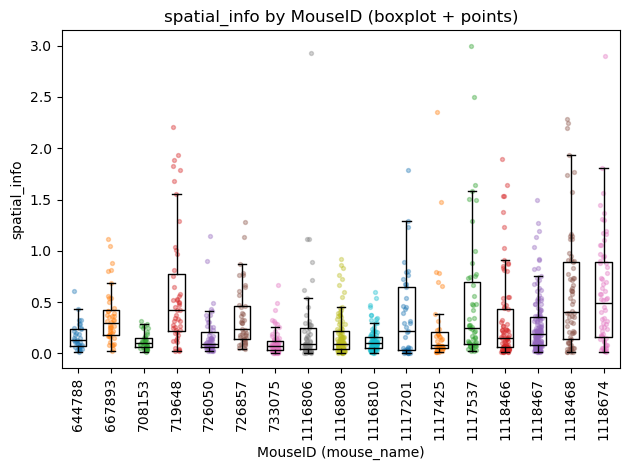

'/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/2.open_field_all_numeric_boxplots_with_points_by_mouse.pdf'

In [6]:
mouse_col = "mouse_name"
mice = sorted(df_open_field[mouse_col].dropna().unique().tolist())
numeric_cols = [c for c in df_open_field.select_dtypes(include=[np.number]).columns if c != mouse_col]

rng = np.random.default_rng(0)

def boxplot_with_points(ax, data, col, mice, jitter=0.12, point_size=8, alpha=0.35, showfliers=False):
    groups = []
    labels = []

    for m in mice:
        vals = data.loc[data[mouse_col] == m, col].dropna().values
        groups.append(vals)
        labels.append(str(m))

    ax.boxplot(
    groups,
    showfliers=showfliers,
    medianprops=dict(color="black", linewidth=1),
)

    # overlay points (jittered)
    for i, vals in enumerate(groups, start=1):
        if len(vals) == 0:
            continue
        x = i + rng.uniform(-jitter, jitter, size=len(vals))
        ax.scatter(x, vals, s=point_size, alpha=alpha)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_xlabel("MouseID (mouse_name)")
    ax.set_ylabel(col)
    ax.set_title(f"{col} by MouseID (boxplot + points)")

# Example plot for spatial_info
plt.figure()
ax = plt.gca()
boxplot_with_points(ax, df_open_field, "spatial_info", mice)
plt.tight_layout()
plt.show()

# Multi-page PDF (save next to the Excel file)
pdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "2.open_field_all_numeric_boxplots_with_points_by_mouse.pdf"
)

with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field dataset\n"
        f"Rows: {len(df_open_field):,} | Columns: {df_open_field.shape[1]:,}\n"
        f"MouseID column: {mouse_col}\n"
        "Contents: one boxplot per numeric column, grouped by MouseID,\n"
        "with individual observations overlaid (jittered points).\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=16, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for col in numeric_cols:
        fig = plt.figure(figsize=(11.69, 8.27))
        ax = fig.add_subplot(111)
        boxplot_with_points(ax, df_open_field, col, mice, jitter=0.12, point_size=6, alpha=0.4, showfliers=False)
        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

pdf_path

### Generate violin plots with overlaid points for all numeric columns, grouped by mouse.
#### Create a multi-page PDF with one plot per numeric column showing distributions across mice.

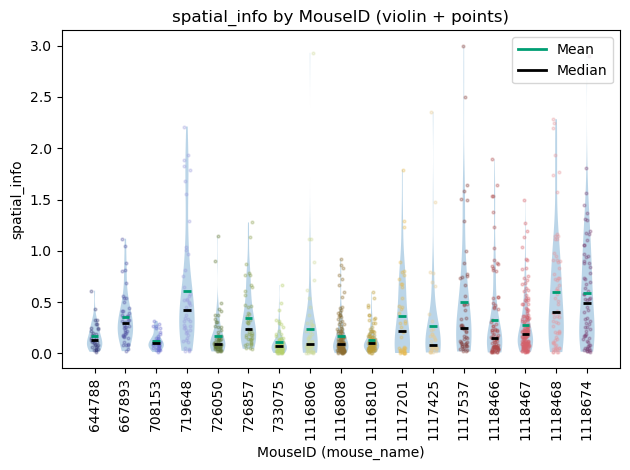

PDF saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/3.open_field_all_numeric_violinplots_with_points_by_mouse.pdf


'/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/3.open_field_all_numeric_violinplots_with_points_by_mouse.pdf'

In [7]:
"""Violin plots with overlaid points (one colour per mouse, using tab20b)
- Mean and median lines styled differently from default (e.g. mean in green, median in black)
- Legend for mean/median line styles (not from tab20/tab20b)
- Points use tab20b, one colour per mouse
"""

mouse_col = "mouse_name"
mice = sorted(df_open_field[mouse_col].dropna().unique().tolist())
numeric_cols = [c for c in df_open_field.select_dtypes(include=[np.number]).columns if c != mouse_col]

rng = np.random.default_rng(0)
point_cmap = plt.get_cmap("tab20b")  # <- use tab20b everywhere for points

# Mean/median legend (NOT from tab20/tab20b)
legend_elements = [
    Line2D([0], [0], color="#009E73", lw=2, linestyle="-", label="Mean"),
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Median"),
]

def violin_with_points(ax, data, col, mice, jitter=0.12, point_size=4, alpha=0.3):
    groups = []
    labels = []
    for m in mice:
        vals = data.loc[data[mouse_col] == m, col].dropna().values
        groups.append(vals)
        labels.append(str(m))

    parts = ax.violinplot(
        groups,
        showmeans=True,
        showmedians=True,
        showextrema=False,
    )

    # Mean / median styling
    if parts.get("cmeans") is not None:
        parts["cmeans"].set_color("#009E73")
        parts["cmeans"].set_linewidth(2)
        parts["cmeans"].set_linestyle("-")

    if parts.get("cmedians") is not None:
        parts["cmedians"].set_color("black")
        parts["cmedians"].set_linewidth(2)
        parts["cmedians"].set_linestyle("-")

    # Overlay points (jittered) — tab20b, one colour per mouse
    for i, vals in enumerate(groups, start=1):
        if len(vals) == 0:
            continue
        x = i + rng.uniform(-jitter, jitter, size=len(vals))
        ax.scatter(
            x,
            vals,
            s=point_size,
            alpha=alpha,
            color=point_cmap((i - 1) % 20),
        )

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_xlabel("MouseID (mouse_name)")
    ax.set_ylabel(col)
    ax.set_title(f"{col} by MouseID (violin + points)")
    ax.legend(handles=legend_elements, loc="upper right")


# Example plot
plt.figure()
ax = plt.gca()
violin_with_points(ax, df_open_field, "spatial_info", mice)
plt.tight_layout()
plt.show()

# Multi-page PDF (PDF uses the function; no extra legend call needed)
savepdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "3.open_field_all_numeric_violinplots_with_points_by_mouse.pdf",
)
print(f"PDF saved to: {savepdf_path}")

with PdfPages(savepdf_path) as pdf:
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field dataset\n"
        f"Rows: {len(df_open_field):,} | Columns: {df_open_field.shape[1]:,}\n"
        f"MouseID column: {mouse_col}\n"
        "Contents: one violin plot per numeric column, grouped by MouseID,\n"
        "with individual observations overlaid (jittered points).\n"
        "Points use tab20b.\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=16, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for col in numeric_cols:
        fig = plt.figure(figsize=(11.69, 8.27))
        ax = fig.add_subplot(111)
        violin_with_points(ax, df_open_field, col, mice)
        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

savepdf_path

In [ ]:
TODO: Fixcode
"""
        r_code = 
        dat$Experimenter <- factor(dat$Experimenter)
        dat$mouse_name   <- factor(dat$mouse_name)
        dat$Age_weeks    <- scale(dat$Age_weeks)

        fit <- lmer(y_response ~ Experimenter * Age_weeks + (1|mouse_name),
                    data = dat,
                    control = lmerControl(optimizer = "bobyqa",
                                          optCtrl = list(maxfun = 1e5),
                                          check.conv.singular = .makeCC(action = "ignore", tol = formals(isSingular)$tol)))

        a3 <- car::Anova(fit, type = 3)
        a3_df <- as.data.frame(a3)
        a3_df$term <- rownames(a3_df)
        rownames(a3_df) <- NULL
        a3_df
scale(dat$Age_weeks) centers and standardises Age_weeks, which helps the optimizer converge. The check.conv.singular = ... line silences the "boundary (singular) fit" message — the model still fits, it just means the random intercept variance for mouse_name is estimated at ~0 for that particular column.
"""

"""Generalised Linear Mixed Model (GLMM) to test for effects of Experimenter and Age_weeks on numeric columns
- Model: y ~ C(Experimenter) + Age_weeks + C(Experimenter):Age_weeks + (1|mouse_name)
- Uses Gaussian family with identity link (equivalent to LMM for continuous outcomes)
- For count data or bounded data, change the family accordingly
- Extract p-values via Type III Wald chi-square tests (car::Anova)
"""

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r("suppressPackageStartupMessages(library(lme4))")
ro.r("suppressPackageStartupMessages(library(car))")

def _sig(p):
    if not np.isfinite(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

glmm_results = []

for col in numeric_cols:
    if col in ['tetrode', 'cluster', 'mouse_name']:
        continue

    test_data = df_open_field[[col, 'Experimenter', 'Age_weeks', 'mouse_name']].dropna()

    if len(test_data) < 10:
        continue
    if test_data['mouse_name'].nunique() < 2:
        continue

    try:
        # Send data to R
        with localconverter(ro.default_converter + pandas2ri.converter):
            r_df = ro.conversion.py2rpy(test_data.rename(columns={col: "y_response"}))

        ro.globalenv["dat"] = r_df

        r_code = """
        dat$Experimenter <- factor(dat$Experimenter)
        dat$mouse_name   <- factor(dat$mouse_name)

        fit <- lmer(y_response ~ Experimenter * Age_weeks + (1|mouse_name),
                    data = dat,
                    control = lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 1e5)))

        # Type III Wald chi-square tests (omnibus p per term)
        a3 <- car::Anova(fit, type = 3)
        a3_df <- as.data.frame(a3)
        a3_df$term <- rownames(a3_df)
        rownames(a3_df) <- NULL
        a3_df
        """
        a3_df = ro.r(r_code)

        with localconverter(ro.default_converter + pandas2ri.converter):
            a3_pd = ro.conversion.rpy2py(a3_df)

        a3_pd = a3_pd.set_index("term")
        pcol = [c for c in a3_pd.columns if "Pr" in c][0]  # "Pr(>Chisq)"

        p_exp = float(a3_pd.loc["Experimenter", pcol]) if "Experimenter" in a3_pd.index else np.nan
        p_age = float(a3_pd.loc["Age_weeks", pcol]) if "Age_weeks" in a3_pd.index else np.nan
        p_int = float(a3_pd.loc["Experimenter:Age_weeks", pcol]) if "Experimenter:Age_weeks" in a3_pd.index else np.nan

        glmm_results.append({
            'column': col,
            'n_observations': len(test_data),
            'n_mice': test_data['mouse_name'].nunique(),
            'p_Experimenter': p_exp,
            'p_Age_weeks': p_age,
            'p_Interaction': p_int,
            'sig_Experimenter': _sig(p_exp),
            'sig_Age_weeks': _sig(p_age),
            'sig_Interaction': _sig(p_int),
        })
    except Exception as e:
        print(f"Could not run GLMM for {col}: {e}")
        continue

df_glmm_results = pd.DataFrame(glmm_results)

display_df("GLMM Results: Experimenter + Age_weeks + Interaction, random intercept = mouse_name", df_glmm_results)

glmm_save_path = os.path.join(OPEN_FIELD_OUTDIR, "4.open_field_glmm_experimenter_age.csv")
df_glmm_results.to_csv(glmm_save_path, index=False)
print(f"\nGLMM results saved to: {glmm_save_path}")

print("\n=== SUMMARY OF SIGNIFICANT EFFECTS (p < 0.05) ===")
print(f"\nExperimenter effects: {(df_glmm_results['sig_Experimenter'].isin(['*','**','***'])).sum()} out of {len(df_glmm_results)} columns")
print(f"Age_weeks effects: {(df_glmm_results['sig_Age_weeks'].isin(['*','**','***'])).sum()} out of {len(df_glmm_results)} columns")
print(f"Interaction effects: {(df_glmm_results['sig_Interaction'].isin(['*','**','***'])).sum()} out of {len(df_glmm_results)} columns")

R callback write-console: Error in eval(predvars, data, env) : object 'Age_weeks' not found
  


Could not run GLMM for Age_weeks: Error in eval(predvars, data, env) : object 'Age_weeks' not found



R callback write-console: boundary (singular) fit: see help('isSingular')
  
R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In optwrap(optimizer, devfun, getStart(start, rho$pp), lower = rho$lower,  :  
R callback write-console: 
   
R callback write-console:  convergence code 3 from bobyqa: bobyqa -- a trust region step failed to reduce q
  
R callback write-console: 2:   
R callback write-console: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :  
R callback write-console: 
   
R callback write-console:  Model failed to converge with max|grad| = 0.091993 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.
  
R callback write-console: 3:   
R callback write-console: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :  
R callback write-console: 
   
R callback write-console:  Model is nearly unidentifiable: very larg

GLMM Results: Experimenter + Age_weeks + Interaction, random intercept = mouse_name


,column,n_observations,n_mice,p_Experimenter,p_Age_weeks,p_Interaction,sig_Experimenter,sig_Age_weeks,sig_Interaction
0,Unnamed: 0,1078,17,0.345545,0.755072,0.308656,ns,ns,ns
1,channel,1078,17,0.641801,0.650615,0.665489,ns,ns,ns
2,num_spikes,1078,17,0.442055,0.810344,0.369785,ns,ns,ns
3,spike_width,1078,17,0.371652,0.645207,0.374960,ns,ns,ns
4,theta_mod_v1,1078,17,0.020949,0.728303,0.029042,*,ns,*
5,theta_mod_v2,1058,17,0.951375,0.679919,0.921721,ns,ns,ns
6,theta_mod_v3,1078,17,0.254235,0.265843,0.295133,ns,ns,ns
7,peak_rate,1078,17,0.932140,0.193645,0.792194,ns,ns,ns
8,mean_rate,1078,17,0.658710,0.572431,0.577141,ns,ns,ns
9,ahp_decay,948,17,0.500109,0.498961,0.653625,ns,ns,ns



GLMM results saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/OpenField_QC_outputs/4.open_field_glmm_experimenter_age.csv

=== SUMMARY OF SIGNIFICANT EFFECTS (p < 0.05) ===

Experimenter effects: 4 out of 28 columns
Age_weeks effects: 0 out of 28 columns
Interaction effects: 4 out of 28 columns


In [ ]:
"""2-way ANOVA to test for effects of Experimenter and Age_weeks on numeric columns
- Use OLS from statsmodels to fit the model: dependent variable ~ C(Experimenter) + Age_weeks + C(Experimenter):Age_weeks
- Extract p-values for Experimenter, Age_weeks, and their interaction
- Create a summary table with columns: column, n_observations, p_Experimenter, p_Age_weeks, p_Interaction, sig_Experimenter, sig_Age_weeks, sig_Interaction
- Significance stars: '***' for p < 0.001, '**' for p < 0.01, '*' for p < 0.05, 'ns' otherwise  
"""

from scipy import stats
import warnings
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings('ignore')

# Prepare data for 2-way ANOVA
# We'll use experimenter and a categorical age variable (since age is continuous, we can use it directly or bin it)
# For 2-way ANOVA with continuous age and categorical experimenter, we'll use OLS from statsmodels


# Create results storage
anova_results = []

# For each numeric column, run 2-way ANOVA with Experimenter and Age_weeks as factors
for col in numeric_cols:
    if col in ['tetrode', 'cluster', 'mouse_name']:
        continue  # Skip ID-type columns
    
    # Prepare data without missing values
    test_data = df_open_field[[col, 'Experimenter', 'Age_weeks']].dropna()
    
    if len(test_data) < 10:  # Skip if too few observations
        continue
    
    try:
        # Fit 2-way ANOVA model: dependent variable ~ factor1 + factor2 + interaction
        formula = f'Q("{col}") ~ C(Experimenter) + Age_weeks + C(Experimenter):Age_weeks'
        model = ols(formula, data=test_data).fit()
        anova_table = anova_lm(model, typ=2)
        
        # Extract p-values
        p_experimenter = anova_table.loc['C(Experimenter)', 'PR(>F)']
        p_age = anova_table.loc['Age_weeks', 'PR(>F)']
        p_interaction = anova_table.loc['C(Experimenter):Age_weeks', 'PR(>F)']
        
        anova_results.append({
            'column': col,
            'n_observations': len(test_data),
            'p_Experimenter': p_experimenter,
            'p_Age_weeks': p_age,
            'p_Interaction': p_interaction,
            'sig_Experimenter': '***' if p_experimenter < 0.001 else '**' if p_experimenter < 0.01 else '*' if p_experimenter < 0.05 else 'ns',
            'sig_Age_weeks': '***' if p_age < 0.001 else '**' if p_age < 0.01 else '*' if p_age < 0.05 else 'ns',
            'sig_Interaction': '***' if p_interaction < 0.001 else '**' if p_interaction < 0.01 else '*' if p_interaction < 0.05 else 'ns',
        })
    except Exception as e:
        print(f"Could not run ANOVA for {col}: {e}")
        continue

# Create results dataframe
df_anova_results = pd.DataFrame(anova_results)

# Display results
display_df("2-way ANOVA Results: Effect of Experimenter and Age_weeks on numeric columns", df_anova_results)

# Save results
anova_save_path = os.path.join(OPEN_FIELD_OUTDIR, "4.open_field_2way_anova_experimenter_age.csv")
df_anova_results.to_csv(anova_save_path, index=False)
print(f"\nANOVA results saved to: {anova_save_path}")

# Summary of significant effects
print("\n=== SUMMARY OF SIGNIFICANT EFFECTS (p < 0.05) ===")
print(f"\nExperimenter effects: {(df_anova_results['sig_Experimenter'] != 'ns').sum()} out of {len(df_anova_results)} columns")
print(f"Age_weeks effects: {(df_anova_results['sig_Age_weeks'] != 'ns').sum()} out of {len(df_anova_results)} columns")
print(f"Interaction effects: {(df_anova_results['sig_Interaction'] != 'ns').sum()} out of {len(df_anova_results)} columns")

Could not run ANOVA for Age_weeks: endog has evaluated to an array with multiple columns that has shape (2214, 2). This occurs when the variable converted to endog is non-numeric (e.g., bool or str).
2-way ANOVA Results: Effect of Experimenter and Age_weeks on numeric columns


,column,n_observations,p_Experimenter,p_Age_weeks,p_Interaction,sig_Experimenter,sig_Age_weeks,sig_Interaction
0,channel,2214,2.689162e-01,1.209207e-01,4.322807e-01,ns,ns,ns
1,peak_rate,2214,7.574177e-09,1.430040e-07,5.140468e-01,***,***,ns
2,mean_firing_rate,2214,2.488296e-03,1.307563e-02,1.879622e-01,**,*,ns
3,num_spikes,2214,1.773803e-03,6.034363e-01,7.401152e-02,**,ns,ns
4,spike_width,2214,9.036878e-05,8.716637e-02,2.221669e-05,***,ns,***
5,AHP_decay,1947,8.966857e-02,2.147666e-01,9.745653e-02,ns,ns,ns
6,theta_modulation,2214,3.165694e-05,4.417056e-03,3.044594e-04,***,**,***
7,field_size,1080,1.893267e-13,2.958144e-10,4.314660e-01,***,***,ns
8,phase_mean,2214,1.469193e-09,1.472586e-01,7.798923e-04,***,ns,***
9,phase_variance,2214,1.725747e-05,1.629899e-01,1.035725e-13,***,ns,***



ANOVA results saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/4.open_field_2way_anova_experimenter_age.csv

=== SUMMARY OF SIGNIFICANT EFFECTS (p < 0.05) ===

Experimenter effects: 16 out of 22 columns
Age_weeks effects: 10 out of 22 columns
Interaction effects: 11 out of 22 columns


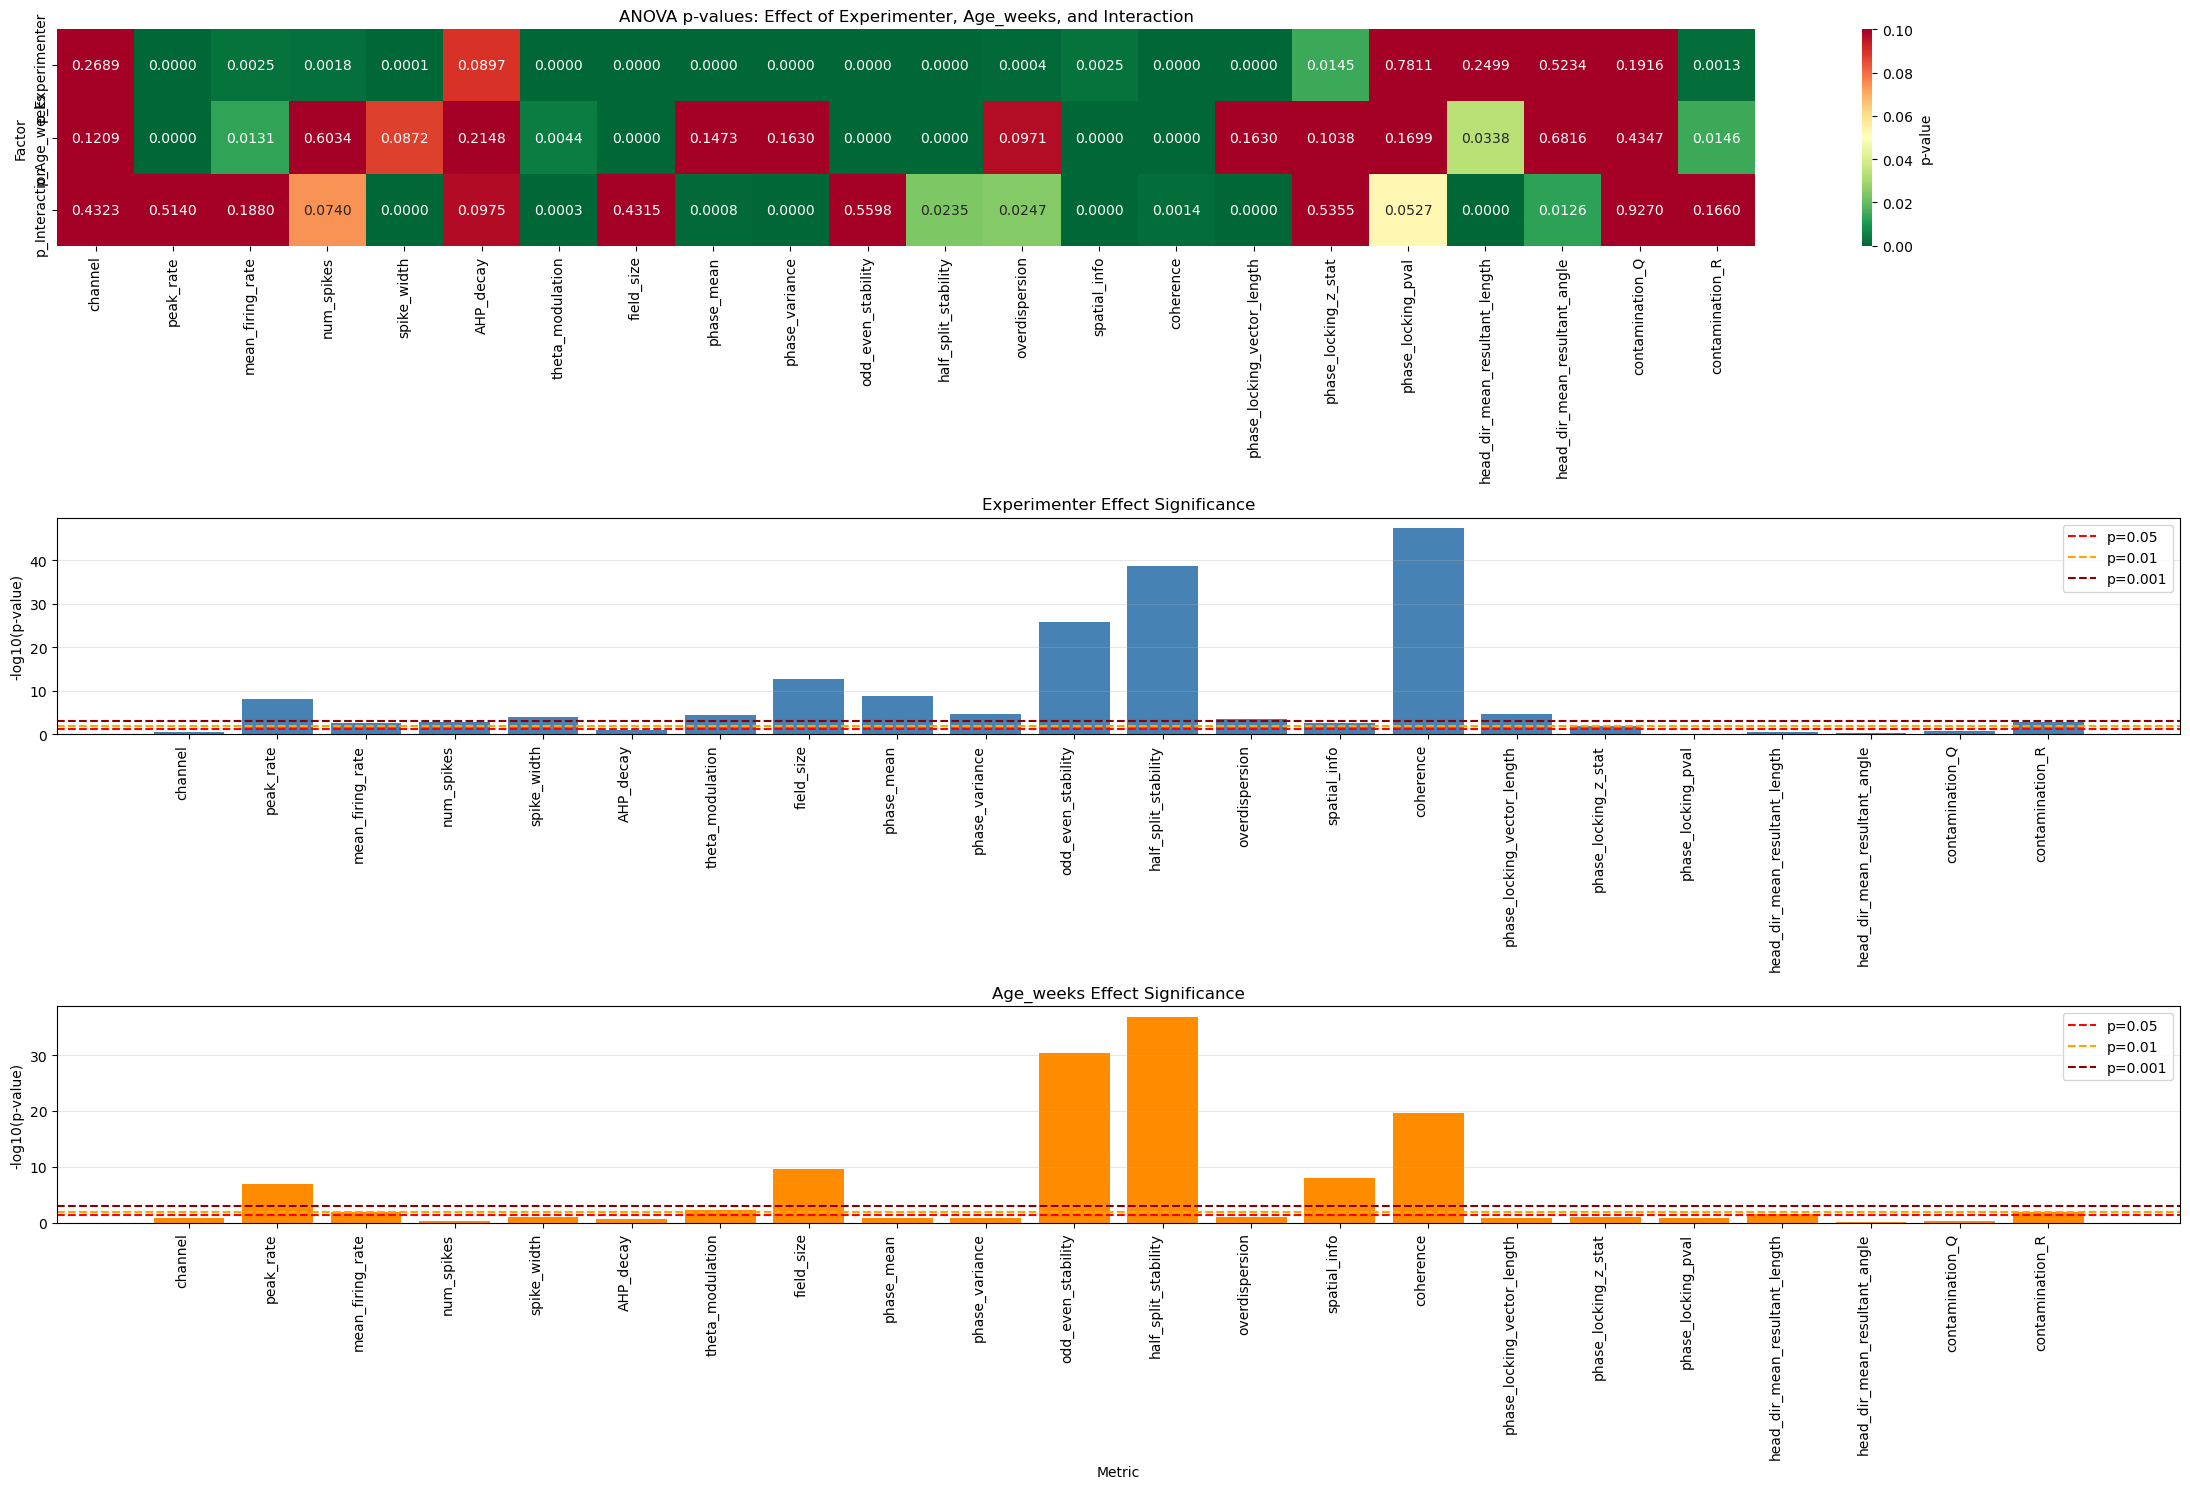


ANOVA visualization saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/4.open_field_anova_results_visualization.pdf


In [ ]:
"""Visualization of ANOVA results
Create a heatmap of p-values
Plot 1: Heatmap of p-values for Experimenter, Age_weeks, and Interaction
Plot 2: Bar plot of -log10(p-values) for Experimenter
Plot 3: Bar plot of -log10(p-values) for Age_weeks

Uses glmer() from R's lme4 with family = gaussian(link = "identity") — for continuous outcomes this is equivalent to an LMM but through the GLMM framework
If a column is count data, change to family = poisson(link = "log"); for proportions, use family = binomial(link = "logit")
p-values come from car::Anova() Type III Wald chi-squaretests, which give proper omnibus p-values per term (not per dummy level)
Requires R packages lme4 and car installed (install.packages(c("lme4", "car")) in R)
"""


import seaborn as sns

# Visualization of ANOVA results

# 1. Create a heatmap of p-values
fig, axes = plt.subplots(3, 1, figsize=(22, 15))

# Prepare data for heatmap
heatmap_data = df_anova_results[['column', 'p_Experimenter', 'p_Age_weeks', 'p_Interaction']].set_index('column')

# Plot 1: Heatmap of p-values
sns.heatmap(heatmap_data.T, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            vmin=0, vmax=0.1, ax=axes[0], cbar_kws={'label': 'p-value'})
axes[0].set_title('ANOVA p-values: Effect of Experimenter, Age_weeks, and Interaction')
axes[0].set_ylabel('Factor')
axes[0].set_xlabel('')

# Plot 2: Bar plot of -log10(p-values) for Experimenter
neg_log_p_exp = -np.log10(df_anova_results['p_Experimenter'])
axes[1].bar(range(len(df_anova_results)), neg_log_p_exp, color='steelblue')
axes[1].axhline(y=-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
axes[1].axhline(y=-np.log10(0.01), color='orange', linestyle='--', label='p=0.01')
axes[1].axhline(y=-np.log10(0.001), color='darkred', linestyle='--', label='p=0.001')
axes[1].set_xticks(range(len(df_anova_results)))
axes[1].set_xticklabels(df_anova_results['column'], rotation=90, ha='right')
axes[1].set_ylabel('-log10(p-value)')
axes[1].set_title('Experimenter Effect Significance')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Bar plot of -log10(p-values) for Age_weeks
neg_log_p_age = -np.log10(df_anova_results['p_Age_weeks'])
axes[2].bar(range(len(df_anova_results)), neg_log_p_age, color='darkorange')
axes[2].axhline(y=-np.log10(0.05), color='red', linestyle='--', label='p=0.05')
axes[2].axhline(y=-np.log10(0.01), color='orange', linestyle='--', label='p=0.01')
axes[2].axhline(y=-np.log10(0.001), color='darkred', linestyle='--', label='p=0.001')
axes[2].set_xticks(range(len(df_anova_results)))
axes[2].set_xticklabels(df_anova_results['column'], rotation=90, ha='right')
axes[2].set_ylabel('-log10(p-value)')
axes[2].set_xlabel('Metric')
axes[2].set_title('Age_weeks Effect Significance')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Save the ANOVA visualization
anova_plot_path = os.path.join(OPEN_FIELD_OUTDIR, "4.open_field_anova_results_visualization.pdf")
fig.savefig(anova_plot_path, bbox_inches='tight')
print(f"\nANOVA visualization saved to: {anova_plot_path}")

In [10]:
""" Visualization of t-test results from experimenter comparison
Plot 1: Bar plot of -log10(p-values) for t-test
Plot 2: Bar plot of -log10(p-values) for Mann–Whitney U test
"""

from scipy.stats import ttest_ind, mannwhitneyu

def _sig_stars(p):
    if p is None or not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

# Create boxplots grouped by Experimenter for all numeric columns
experimenters = sorted(df_open_field["Experimenter"].dropna().unique().tolist())

pdf_experimenter_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "5.open_field_boxplots_by_experimenter.pdf"
)

experimenter_stats = []

with PdfPages(pdf_experimenter_path) as pdf:
    # Title page
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field dataset - Analysis by Experimenter\n"
        f"Rows: {len(df_open_field):,} | Columns: {df_open_field.shape[1]:,}\n"
        f"Experimenters: {', '.join(map(str, experimenters))}\n"
        "Contents: one boxplot per numeric column, grouped by Experimenter,\n"
        "with individual observations overlaid (jittered points).\n"
        "Each page is annotated with Mann–Whitney U (and t-test) results when 2 groups are present.\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=16, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    cols_to_plot = [c for c in numeric_cols if c not in ["tetrode", "cluster", "mouse_name", "Age_weeks"]]

    for col in cols_to_plot:
        fig = plt.figure(figsize=(11.69, 8.27))
        ax = fig.add_subplot(111)

        # Prepare data per experimenter
        groups = []
        ns = []
        for exp in experimenters:
            vals = df_open_field.loc[df_open_field["Experimenter"] == exp, col].dropna().values.astype(float)
            groups.append(vals)
            ns.append(len(vals))

        # Per-group summaries (always shown)
        group_summary_lines = []
        for exp, vals in zip(experimenters, groups):
            if len(vals) == 0:
                group_summary_lines.append(f"{exp}: n=0, mean=NA, median=NA")
            else:
                group_summary_lines.append(
                    f"{exp}: n={len(vals)}, mean={np.mean(vals):.3g}, median={np.median(vals):.3g}"
                )

        # Boxplot + points
        ax.boxplot(groups, showfliers=False, medianprops=dict(color="black", linewidth=1))
        for i, vals in enumerate(groups, start=1):
            if len(vals) == 0:
                continue
            x = i + rng.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(x, vals, s=6, alpha=0.4)

        ax.set_xticks(range(1, len(experimenters) + 1))
        ax.set_xticklabels([str(e) for e in experimenters], rotation=0)
        ax.set_xlabel("Experimenter")
        ax.set_ylabel(col)
        ax.set_title(f"{col} by Experimenter")

        # --- Stats + annotation (only meaningful when exactly 2 experimenters) ---
        t_pval = np.nan
        u_stat = np.nan
        u_pval = np.nan
        stat_note = ""

        if len(experimenters) == 2:
            g1, g2 = groups[0], groups[1]
            if (len(g1) >= 3) and (len(g2) >= 3):
                # t-test
                try:
                    _, t_pval = ttest_ind(g1, g2, nan_policy="omit")
                except Exception:
                    t_pval = np.nan

                # Mann–Whitney U
                try:
                    u_stat, u_pval = mannwhitneyu(g1, g2, alternative="two-sided")
                except Exception:
                    u_stat, u_pval = np.nan, np.nan

                stat_note = (
                    f"t-test p={t_pval:.3g} ({_sig_stars(t_pval)})\n"
                    f"Mann–Whitney U={u_stat:.3g}, p={u_pval:.3g} ({_sig_stars(u_pval)})\n"
                    + "\n".join(group_summary_lines)
                )
            else:
                stat_note = f"Stats not run (need n>=3 per group)\n" f"n={ns[0]} vs {ns[1]}"
        else:
            stat_note = f"Mann–Whitney shown only for 2 groups\n(groups found: {len(experimenters)})"

        ax.text(
            0.98, 0.98, stat_note,
            transform=ax.transAxes,
            ha="right", va="top",
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8),
        )

        # Save stats row (only if 2 groups and enough data)
        if len(experimenters) == 2 and (ns[0] >= 3) and (ns[1] >= 3):
            exp1, exp2 = experimenters[0], experimenters[1]
            experimenter_stats.append({
                "column": col,
                f"n_{exp1}": ns[0],
                f"n_{exp2}": ns[1],
                f"mean_{exp1}": float(np.mean(groups[0])) if ns[0] else np.nan,
                f"mean_{exp2}": float(np.mean(groups[1])) if ns[1] else np.nan,
                f"median_{exp1}": float(np.median(groups[0])) if ns[0] else np.nan,
                f"median_{exp2}": float(np.median(groups[1])) if ns[1] else np.nan,
                "t_pval": float(t_pval) if np.isfinite(t_pval) else np.nan,
                "t_sig": _sig_stars(t_pval),
                "mann_whitney_u": float(u_stat) if np.isfinite(u_stat) else np.nan,
                "mann_whitney_pval": float(u_pval) if np.isfinite(u_pval) else np.nan,
                "mw_sig": _sig_stars(u_pval),
            })

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Experimenter boxplots saved to: {pdf_experimenter_path}")

# Save stats table (if any)
df_experimenter_stats = pd.DataFrame(experimenter_stats)
display_df("Statistical Tests: Differences between Experimenters", df_experimenter_stats)

experimenter_stats_path = os.path.join(OPEN_FIELD_OUTDIR, "5.open_field_experimenter_statistics.csv")
df_experimenter_stats.to_csv(experimenter_stats_path, index=False)
print(f"\nExperimenter statistics saved to: {experimenter_stats_path}")

Experimenter boxplots saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/5.open_field_boxplots_by_experimenter.pdf
Statistical Tests: Differences between Experimenters


,column,n_Loukia,n_Ruth,mean_Loukia,mean_Ruth,median_Loukia,median_Ruth,t_pval,t_sig,mann_whitney_u,mann_whitney_pval,mw_sig
0,channel,1555,659,4.282958,4.274659,4.000000,4.000000,9.343294e-01,ns,515626.0,8.114358e-01,ns
1,peak_rate,1555,659,4.105329,3.429087,2.354945,1.829796,5.586156e-03,**,566016.0,9.603473e-05,***
2,mean_firing_rate,1555,659,1.702111,1.431880,0.606994,0.524503,7.835521e-02,ns,536808.0,7.562153e-02,ns
3,num_spikes,1555,659,1750.841801,1151.449165,642.000000,446.000000,3.788291e-05,***,585402.5,1.096210e-07,***
4,spike_width,1555,659,403.701030,375.460655,469.387755,428.571429,7.598047e-05,***,579842.5,8.923362e-07,***
5,AHP_decay,1386,561,338.408929,347.097256,345.206431,369.939327,2.466709e-01,ns,350651.5,6.910462e-04,***
6,theta_modulation,1555,659,0.055658,0.043412,0.035802,0.027488,2.255824e-03,**,555101.0,1.891466e-03,**
7,field_size,790,290,72.646486,61.066312,67.885781,54.613281,3.103084e-05,***,132620.0,6.963821e-05,***
8,phase_mean,1555,659,3.032654,3.549971,3.182747,3.700098,9.336129e-14,***,404076.0,3.428391e-15,***
9,phase_variance,1555,659,0.853293,0.815433,0.873326,0.834909,2.670023e-15,***,623993.0,4.821097e-16,***



Experimenter statistics saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/5.open_field_experimenter_statistics.csv


Saved figure to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/5.open_field_experimenter_stats_visualization.pdf


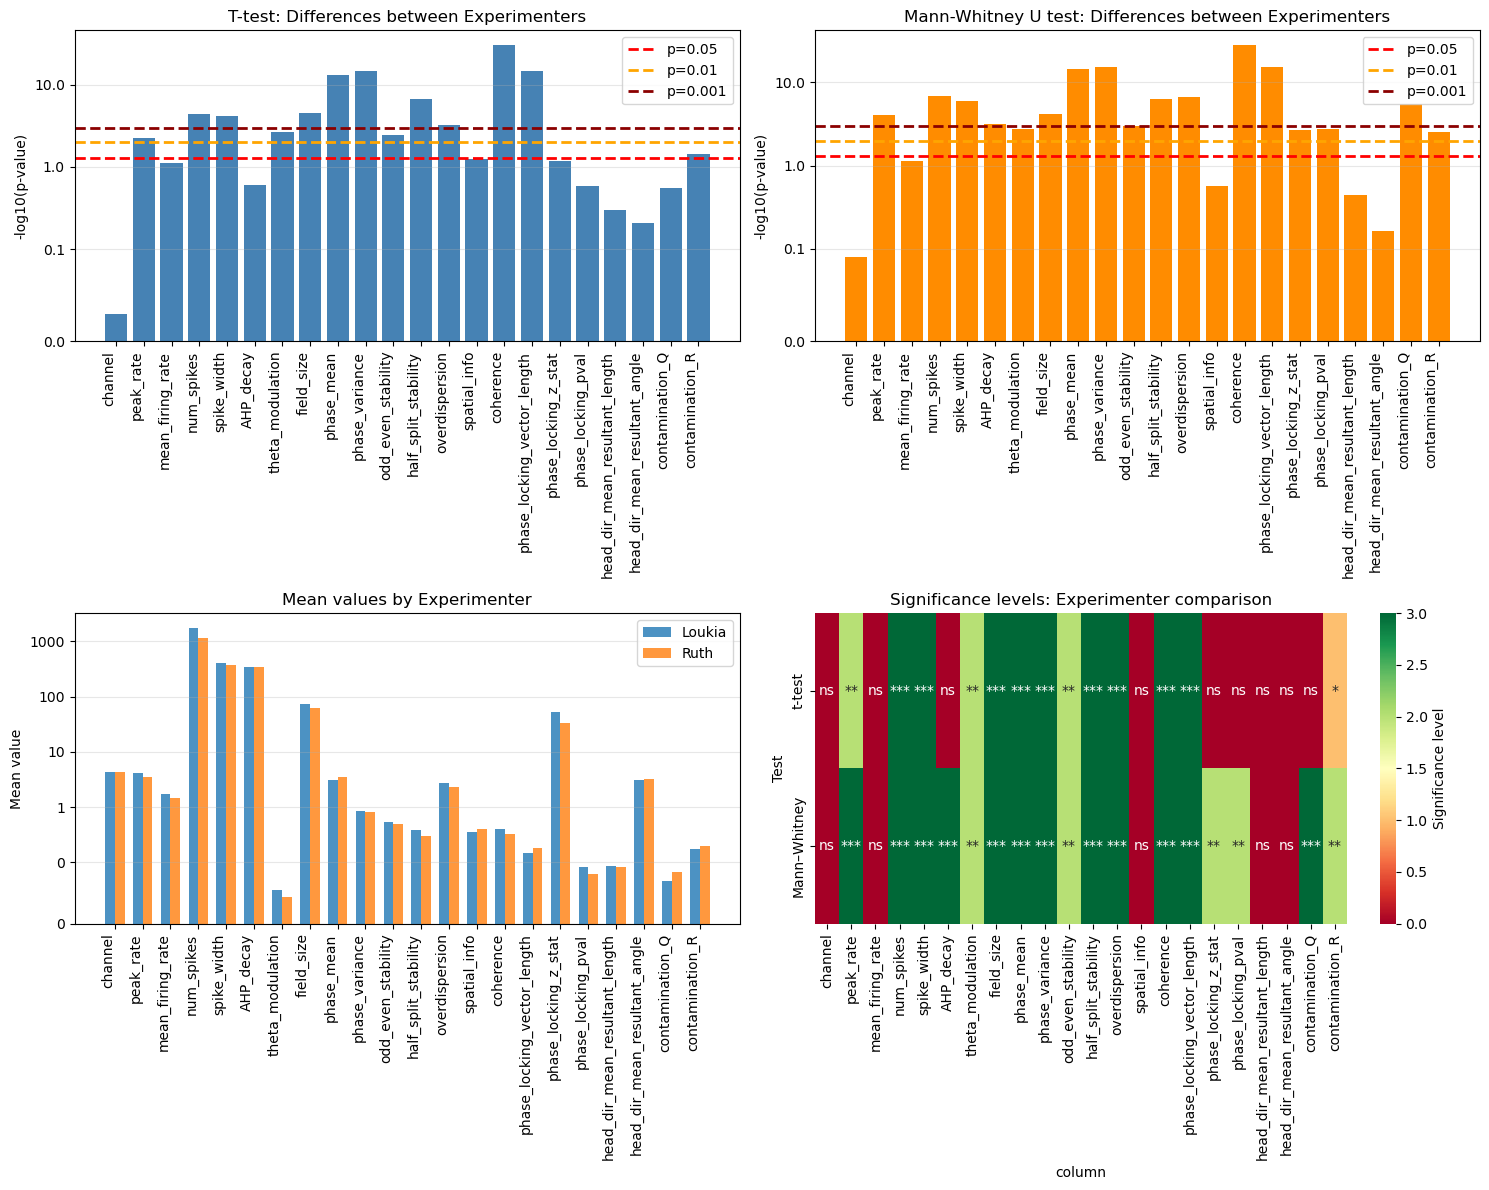

In [11]:
# Visualization of t-test results from experimenter comparison

from matplotlib.ticker import ScalarFormatter

fig, axes = plt.subplots(2, 2, figsize=(15, 12) )

# Plot 1: Bar plot of -log10(p-values) for t-test
ax = axes[0, 0]
neg_log_p_ttest = -np.log10(df_experimenter_stats['t_pval'])
bars = ax.bar(range(len(df_experimenter_stats)), neg_log_p_ttest, color='steelblue')
# Log-like y scale so small bars are visible (works even with zeros)
ax.set_yscale("symlog", linthresh=0.1)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="y", style="plain")
ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', label='p=0.05', linewidth=2)
ax.axhline(y=-np.log10(0.01), color='orange', linestyle='--', label='p=0.01', linewidth=2)
ax.axhline(y=-np.log10(0.001), color='darkred', linestyle='--', label='p=0.001', linewidth=2)
ax.set_xticks(range(len(df_experimenter_stats)))
ax.set_xticklabels(df_experimenter_stats['column'], rotation=90, ha='right')
ax.set_ylabel('-log10(p-value)')
ax.set_title('T-test: Differences between Experimenters')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Bar plot of -log10(p-values) for Mann-Whitney U test
ax = axes[0, 1]
neg_log_p_mw = -np.log10(df_experimenter_stats['mann_whitney_pval'])
bars = ax.bar(range(len(df_experimenter_stats)), neg_log_p_mw, color='darkorange')
# Log-like y scale so small bars are visible (works even with zeros)
ax.set_yscale("symlog", linthresh=0.1)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="y", style="plain")
ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', label='p=0.05', linewidth=2)
ax.axhline(y=-np.log10(0.01), color='orange', linestyle='--', label='p=0.01', linewidth=2)
ax.axhline(y=-np.log10(0.001), color='darkred', linestyle='--', label='p=0.001', linewidth=2)
ax.set_xticks(range(len(df_experimenter_stats)))
ax.set_xticklabels(df_experimenter_stats['column'], rotation=90, ha='right')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Mann-Whitney U test: Differences between Experimenters')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: Comparison of means between experimenters
ax = axes[1, 0]
x_pos = np.arange(len(df_experimenter_stats))
width = 0.35
exp1, exp2 = experimenters[0], experimenters[1]
bars1 = ax.bar(x_pos - width/2, df_experimenter_stats[f'mean_{exp1}'], width, label=exp1, alpha=0.8)
bars2 = ax.bar(x_pos + width/2, df_experimenter_stats[f'mean_{exp2}'], width, label=exp2, alpha=0.8)
# Log-like y scale so small bars are visible (works even with zeros)
ax.set_yscale("symlog", linthresh=0.1)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="y", style="plain")
ax.set_xticks(x_pos)
ax.set_xticklabels(df_experimenter_stats['column'], rotation=90, ha='right')
ax.set_ylabel('Mean value')
ax.set_title('Mean values by Experimenter')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 4: Heatmap of significance
ax = axes[1, 1]

# be robust to either naming convention
t_sig_col = "sig_ttest" if "sig_ttest" in df_experimenter_stats.columns else "t_sig"
mw_sig_col = "sig_mannwhitney" if "sig_mannwhitney" in df_experimenter_stats.columns else "mw_sig"

sig_data = df_experimenter_stats[["column", t_sig_col, mw_sig_col]].set_index("column")
sig_data = sig_data.rename(columns={t_sig_col: "t-test", mw_sig_col: "Mann–Whitney"})

sig_numeric = sig_data.replace({"***": 3, "**": 2, "*": 1, "ns": 0, "NA": np.nan})

sns.heatmap(
    sig_numeric.T,
    annot=sig_data.T.values,
    fmt="",
    cmap="RdYlGn",
    vmin=0,
    vmax=3,
    ax=ax,
    cbar_kws={"label": "Significance level"},
)
ax.set_title("Significance levels: Experimenter comparison")
ax.set_ylabel("Test")

plt.tight_layout()

# choose output folder: prefer OPEN_FIELD_OUTDIR if you created it
out_dir = OPEN_FIELD_OUTDIR if "OPEN_FIELD_OUTDIR" in globals() else OPEN_FIELD_DIR
pdf_path = os.path.join(out_dir, "5.open_field_experimenter_stats_visualization.pdf")

fig.savefig(pdf_path, bbox_inches="tight")
print("Saved figure to:", pdf_path)

plt.show()

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import re


import warnings
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings("ignore")


EXPERIMENTER_COL = "Experimenter"

def _find_col(df, names):
    def norm(s):
        return re.sub(r"[\s_]+", "", str(s)).lower()
    norm_map = {norm(c): c for c in df.columns}
    for n in names:
        key = norm(n)
        if key in norm_map:
            return norm_map[key]
    raise KeyError(f"Could not find any of {names}. Available columns: {list(df.columns)}")

CELLTYPE_COL = _find_col(df_open_field, ["Cell Type", "Cell type", "cell_type", "celltype"])
print("Using CELLTYPE_COL =", CELLTYPE_COL)

def _sig_stars(p):
    if p is None or not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

# numeric metrics to analyze/plot
numeric_cols = df_open_field.select_dtypes(include=[np.number]).columns.tolist()
cols_to_use = [c for c in numeric_cols if c not in ["tetrode", "cluster", "mouse_name"]]

# ---------- 1) 2-way ANOVA: Experimenter x Cell type ----------
anova_rows = []
term_exp = f'C(Q("{EXPERIMENTER_COL}"))'
term_ct  = f'C(Q("{CELLTYPE_COL}"))'
term_int = f'{term_exp}:{term_ct}'

for col in cols_to_use:
    test_data = df_open_field[[col, EXPERIMENTER_COL, CELLTYPE_COL]].dropna()
    if len(test_data) < 10:
        continue
    if test_data[EXPERIMENTER_COL].nunique() < 2 or test_data[CELLTYPE_COL].nunique() < 2:
        continue

    try:
        formula = f'Q("{col}") ~ {term_exp} * {term_ct}'
        model = ols(formula, data=test_data).fit()
        aov = anova_lm(model, typ=2)

        p_exp = float(aov.loc[term_exp, "PR(>F)"]) if term_exp in aov.index else np.nan
        p_ct  = float(aov.loc[term_ct,  "PR(>F)"]) if term_ct  in aov.index else np.nan
        p_int = float(aov.loc[term_int, "PR(>F)"]) if term_int in aov.index else np.nan

        anova_rows.append({
            "column": col,
            "n_observations": int(len(test_data)),
            "n_experimenters": int(test_data[EXPERIMENTER_COL].nunique()),
            "n_cell_types": int(test_data[CELLTYPE_COL].nunique()),
            "p_Experimenter": p_exp,
            "p_CellType": p_ct,
            "p_Interaction": p_int,
            "sig_Experimenter": _sig_stars(p_exp),
            "sig_CellType": _sig_stars(p_ct),
            "sig_Interaction": _sig_stars(p_int),
        })
    except Exception as e:
        print(f"Could not run ANOVA for {col}: {e}")

df_anova_exp_celltype = pd.DataFrame(anova_rows).sort_values("p_Experimenter", na_position="last")
display_df("2-way ANOVA: Experimenter x Cell type", df_anova_exp_celltype)

anova_save_path = os.path.join(OPEN_FIELD_OUTDIR, "6.open_field_2way_anova_experimenter_celltype.csv")
df_anova_exp_celltype.to_csv(anova_save_path, index=False)
print(f"Saved ANOVA table to: {anova_save_path}")

# ---------- 2) Boxplots PDF: metric by Cell type (hue=Experimenter) ----------
pdf_path = os.path.join(OPEN_FIELD_OUTDIR, "6.open_field_boxplots_by_experimenter_and_celltype.pdf")

with PdfPages(pdf_path) as pdf:
    # title page
    fig = plt.figure(figsize=(11.69, 8.27))
    exp_levels = sorted(df_open_field[EXPERIMENTER_COL].dropna().unique().tolist())
    ct_levels  = sorted(df_open_field[CELLTYPE_COL].dropna().unique().tolist())
    txt = (
        "Open field dataset - Boxplots by Experimenter and Cell type\n"
        f"Experimenters: {', '.join(map(str, exp_levels))}\n"
        f"Cell types: {', '.join(map(str, ct_levels))}\n"
        "Each page: boxplot (no fliers) + jittered points\n"
        "Median: black diamond + printed value\n"
        "x = Cell type, hue = Experimenter\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=14, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Use the same ordering on every page
    x_order   = ct_levels if len(ct_levels) else None
    hue_order = exp_levels if len(exp_levels) else None

    for col in cols_to_use:
        plot_data = df_open_field[[col, EXPERIMENTER_COL, CELLTYPE_COL]].dropna()
        if plot_data.empty or plot_data[CELLTYPE_COL].nunique() < 2:
            continue

        fig = plt.figure(figsize=(11.69, 8.27))
        ax = fig.add_subplot(111)


    # ---- palette: Ruth lighter blue, Loukia lighter orange ----
        # Clean labels (avoids hidden spaces causing key mismatches)
        plot_data[EXPERIMENTER_COL] = plot_data[EXPERIMENTER_COL].astype(str).str.strip()

        hue_order = ["Ruth", "Loukia"]
        hue_order = [h for h in hue_order if h in plot_data[EXPERIMENTER_COL].unique()]

        palette = {
            "Ruth": sns.color_palette("Blues", 6)[2],
            "Loukia": sns.color_palette("Oranges", 6)[2],
        }
        # --- boxplot ---
        sns.boxplot(
            data=plot_data,
            x=CELLTYPE_COL,
            y=col,
            hue=EXPERIMENTER_COL,
            hue_order=hue_order,
            palette=palette,
            showfliers=False,
            ax=ax,
        )
        
        sns.stripplot(
            data=plot_data,
            x=CELLTYPE_COL,
            y=col,
            hue=EXPERIMENTER_COL,
            hue_order=hue_order,
            palette=palette,
            dodge=True,
            jitter=0.28,
            size=2.5,
            alpha=0.35,
            linewidth=0.25,
            ax=ax,
        )


        # ---- Median overlay (diamond) using seaborn dodge logic ----
        try:
            sns.pointplot(
                data=plot_data,
                x=CELLTYPE_COL, y=col, hue=EXPERIMENTER_COL,
                order=x_order, hue_order=hue_order,
                estimator=np.median,
                errorbar=None,      # seaborn >= 0.12
                join=False,
                dodge=0.4,
                markers="D",
                scale=0.75,
                color="black",
                ax=ax,
                legend=False,
            )
        except TypeError:
            sns.pointplot(
                data=plot_data,
                x=CELLTYPE_COL, y=col, hue=EXPERIMENTER_COL,
                order=x_order, hue_order=hue_order,
                estimator=np.median,
                ci=None,            # seaborn < 0.12
                join=False,
                dodge=0.4,
                markers="D",
                scale=0.75,
                color="black",
                ax=ax,
                legend=False,
            )

        # ---- Median value labels above each diamond ----
        # Resolve hue_order if None
        local_hue_order = hue_order
        if local_hue_order is None:
            local_hue_order = sorted(plot_data[EXPERIMENTER_COL].dropna().unique().tolist())

        y0, y1 = ax.get_ylim()
        label_pad = 0.01 * (y1 - y0)

        # pointplot adds one Line2D per hue; grab the last len(hue) lines (these are the medians)
        median_lines = ax.lines[-len(local_hue_order):] if len(local_hue_order) else []
        for ln in median_lines:
            ln.set_label("_nolegend_")
            for x, y in zip(ln.get_xdata(), ln.get_ydata()):
                if np.isfinite(y):
                    ax.text(
                        x, y + label_pad, f"{y:.3g}",
                        ha="center", va="bottom",
                        fontsize=7, fontweight="bold",
                        zorder=10,
                    )

        # ---- single clean legend from the boxplot only ----
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            title=EXPERIMENTER_COL,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0,
        )

        ax.set_title(f"{col} by Cell type (hue=Experimenter)")
        ax.set_xlabel(CELLTYPE_COL)
        ax.set_ylabel(col)
        ax.tick_params(axis="x", rotation=45)

        fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"Saved boxplots PDF to: {pdf_path}")


Using CELLTYPE_COL = Cell type
2-way ANOVA: Experimenter x Cell type


,column,n_observations,n_experimenters,n_cell_types,p_Experimenter,p_CellType,p_Interaction,sig_Experimenter,sig_CellType,sig_Interaction
18,Age_weeks,2214,2,2,0.000000e+00,4.041882e-01,3.364602e-04,***,ns,***
14,coherence,2214,2,2,5.442281e-31,1.196880e-61,8.672420e-04,***,***,***
15,phase_locking_vector_length,2214,2,2,4.412856e-15,6.926073e-03,4.042876e-07,***,**,***
9,phase_variance,2214,2,2,4.412856e-15,6.926073e-03,4.042876e-07,***,**,***
8,phase_mean,2214,2,2,2.907329e-13,2.283481e-05,2.052023e-01,***,***,ns
3,num_spikes,2214,2,2,5.346658e-07,6.274126e-54,2.240728e-04,***,***,***
11,half_split_stability,2186,2,2,1.551649e-06,7.452706e-57,1.257200e-01,***,***,ns
4,spike_width,2214,2,2,1.574526e-06,0.000000e+00,4.303684e-01,***,***,ns
7,field_size,1080,2,2,5.765287e-05,2.365905e-10,9.622740e-04,***,***,***
12,overdispersion,2214,2,2,5.023569e-04,5.696922e-01,2.433764e-01,***,ns,ns


Saved ANOVA table to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/6.open_field_2way_anova_experimenter_celltype.csv
Saved boxplots PDF to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/6.open_field_boxplots_by_experimenter_and_celltype.pdf


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import re

import warnings
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings("ignore")

EXPERIMENTER_COL = "Experimenter"

def _find_col(df, names):
    def norm(s):
        return re.sub(r"[\s_]+", "", str(s)).lower()
    norm_map = {norm(c): c for c in df.columns}
    for n in names:
        key = norm(n)
        if key in norm_map:
            return norm_map[key]
    raise KeyError(f"Could not find any of {names}. Available columns: {list(df.columns)}")

CELLTYPE_COL = _find_col(df_open_field, ["Cell Type", "Cell type", "cell_type", "celltype"])
GENOTYPE_COL = _find_col(df_open_field, ["Phenotype", "genotype", "geno", "genotype_group", "Genotype group"])

print("Using CELLTYPE_COL =", CELLTYPE_COL)
print("Using GENOTYPE_COL =", GENOTYPE_COL)

def _sig_stars(p):
    if p is None or not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

# numeric metrics to analyze/plot
numeric_cols = df_open_field.select_dtypes(include=[np.number]).columns.tolist()
cols_to_use = [c for c in numeric_cols if c not in ["tetrode", "cluster", "mouse_name"]]

genotype_levels = sorted(df_open_field[GENOTYPE_COL].dropna().unique().tolist())
print("Genotypes found:", genotype_levels)

# ---------- 1) 2-way ANOVA within each genotype: Experimenter x Cell type ----------
anova_rows = []
term_exp = f'C(Q("{EXPERIMENTER_COL}"))'
term_ct  = f'C(Q("{CELLTYPE_COL}"))'
term_int = f'{term_exp}:{term_ct}'

for geno in genotype_levels:
    df_g = df_open_field.loc[df_open_field[GENOTYPE_COL] == geno]

    for col in cols_to_use:
        test_data = df_g[[col, EXPERIMENTER_COL, CELLTYPE_COL]].dropna()
        if len(test_data) < 10:
            continue
        if test_data[EXPERIMENTER_COL].nunique() < 2 or test_data[CELLTYPE_COL].nunique() < 2:
            continue

        try:
            formula = f'Q("{col}") ~ {term_exp} * {term_ct}'
            model = ols(formula, data=test_data).fit()
            aov = anova_lm(model, typ=2)

            p_exp = float(aov.loc[term_exp, "PR(>F)"]) if term_exp in aov.index else np.nan
            p_ct  = float(aov.loc[term_ct,  "PR(>F)"]) if term_ct  in aov.index else np.nan
            p_int = float(aov.loc[term_int, "PR(>F)"]) if term_int in aov.index else np.nan

            anova_rows.append({
                "genotype": str(geno),
                "column": col,
                "n_observations": int(len(test_data)),
                "n_experimenters": int(test_data[EXPERIMENTER_COL].nunique()),
                "n_cell_types": int(test_data[CELLTYPE_COL].nunique()),
                "p_Experimenter": p_exp,
                "p_CellType": p_ct,
                "p_Interaction": p_int,
                "sig_Experimenter": _sig_stars(p_exp),
                "sig_CellType": _sig_stars(p_ct),
                "sig_Interaction": _sig_stars(p_int),
            })
        except Exception as e:
            print(f"[{geno}] Could not run ANOVA for {col}: {e}")

df_anova_by_genotype = pd.DataFrame(anova_rows)
display_df("2-way ANOVA (within each genotype): Experimenter x Cell type", df_anova_by_genotype)

anova_save_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "7.open_field_2way_anova_experimenter_celltype_split_by_genotype.csv",
)
df_anova_by_genotype.to_csv(anova_save_path, index=False)
print(f"Saved genotype-split ANOVA table to: {anova_save_path}")

# ---------- 2) Boxplots PDF split by genotype: metric by Cell type (hue=Experimenter) ----------
pdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    "7.open_field_boxplots_by_experimenter_and_celltype_split_by_genotype.pdf",
)

with PdfPages(pdf_path) as pdf:
    # overall title page
    fig = plt.figure(figsize=(11.69, 8.27))
    txt = (
        "Open field dataset - Boxplots by Experimenter and Cell type, split by Genotype\n"
        f"Genotype column: {GENOTYPE_COL}\n"
        f"Genotypes: {', '.join(map(str, genotype_levels))}\n"
        "Each genotype section: one page per metric\n"
        "Median: black diamond + printed value\n"
        "Each page: boxplot (no fliers) + jittered points; x = Cell type, hue = Experimenter\n"
    )
    fig.text(0.05, 0.9, txt, fontsize=14, va="top")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for geno in genotype_levels:
        df_g = df_open_field.loc[df_open_field[GENOTYPE_COL] == geno]

        exp_levels = sorted(df_g[EXPERIMENTER_COL].dropna().unique().tolist())
        ct_levels = sorted(df_g[CELLTYPE_COL].dropna().unique().tolist())

        # genotype section title page
        fig = plt.figure(figsize=(11.69, 8.27))
        txt = (
            f"{GENOTYPE_COL} = {geno}\n"
            f"Experimenters: {', '.join(map(str, exp_levels)) if exp_levels else 'NA'}\n"
            f"Cell types: {', '.join(map(str, ct_levels)) if ct_levels else 'NA'}\n"
        )
        fig.text(0.05, 0.9, txt, fontsize=16, va="top")
        plt.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

        for col in cols_to_use:
            plot_data = df_g[[col, EXPERIMENTER_COL, CELLTYPE_COL]].dropna()
            if len(plot_data) == 0:
                continue
            if plot_data[CELLTYPE_COL].nunique() < 2:
                continue
            
            hue_order = ["Ruth", "Loukia"]
            hue_order = [h for h in hue_order if h in plot_data[EXPERIMENTER_COL].unique()]

            palette = {
                "Ruth": sns.color_palette("Blues", 6)[2],
                "Loukia": sns.color_palette("Oranges", 6)[2],
            }
            

            fig = plt.figure(figsize=(11.69, 8.27))
            ax = fig.add_subplot(111)

            sns.boxplot(
                data=plot_data,
                x=CELLTYPE_COL,
                y=col,
                hue=EXPERIMENTER_COL,
                # order=ct_levels if len(ct_levels) else None,
                hue_order=hue_order,
                palette= palette,
                showfliers=False,
                ax=ax,
            )
            sns.stripplot(
                data=plot_data,
                x=CELLTYPE_COL,
                y=col,
                hue=EXPERIMENTER_COL,
                # order=ct_levels if len(ct_levels) else None,
                hue_order=hue_order,
                palette= palette,
                dodge=True,
                jitter=0.2,
                size=2.5,
                alpha=0.35,
                linewidth=0.25,
                ax=ax,
            )

            # ---- Median overlay (diamond) using seaborn dodge logic ----
            try:
                sns.pointplot(
                    data=plot_data,
                    x=CELLTYPE_COL, y=col, hue=EXPERIMENTER_COL,
                    order=x_order, hue_order=hue_order,
                    estimator=np.median,
                    errorbar=None,      # seaborn >= 0.12
                    join=False,
                    dodge=0.4,
                    markers="D",
                    scale=0.75,
                    color="black",
                    ax=ax,
                    legend=False,
                )
            except TypeError:
                sns.pointplot(
                    data=plot_data,
                    x=CELLTYPE_COL, y=col, hue=EXPERIMENTER_COL,
                    order=x_order, hue_order=hue_order,
                    estimator=np.median,
                    ci=None,            # seaborn < 0.12
                    join=False,
                    dodge=0.4,
                    markers="D",
                    scale=0.75,
                    color="black",
                    ax=ax,
                    legend=False,
                )

            # ---- Median value labels above each diamond ----
            # pointplot adds one Line2D per hue; grab the last len(hue) lines (these are the medians)
            median_lines = ax.lines[-len(local_hue_order):] if len(local_hue_order) else []
            for ln in median_lines:
                ln.set_label("_nolegend_")
                for x, y in zip(ln.get_xdata(), ln.get_ydata()):
                    if np.isfinite(y):
                        ax.text(
                            x, y + label_pad, f"{y:.3g}",
                            ha="center", va="bottom",
                            fontsize=7, fontweight="bold",
                            zorder=10,
                        )

            
            # de-duplicate legend (boxplot + stripplot both add)
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(
                by_label.values(),
                by_label.keys(),
                title=EXPERIMENTER_COL,
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                borderaxespad=0,
            )

            ax.set_title(f"{col} by Cell type (hue=Experimenter) | {GENOTYPE_COL}={geno}")
            ax.set_xlabel(CELLTYPE_COL)
            ax.set_ylabel(col)
            ax.tick_params(axis="x", rotation=45)

            fig.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

print(f"Saved genotype-split boxplots PDF to: {pdf_path}")

Using CELLTYPE_COL = Cell type
Using GENOTYPE_COL = Genotype
Genotypes found: ['NLGF', 'WT']
2-way ANOVA (within each genotype): Experimenter x Cell type


,genotype,column,n_observations,n_experimenters,n_cell_types,p_Experimenter,p_CellType,p_Interaction,sig_Experimenter,sig_CellType,sig_Interaction
0,NLGF,channel,1058,2,2,7.952625e-01,9.356750e-04,9.436852e-01,ns,***,ns
1,NLGF,peak_rate,1058,2,2,9.429493e-01,7.826378e-18,8.065971e-01,ns,***,ns
2,NLGF,mean_firing_rate,1058,2,2,5.115056e-01,3.133997e-26,9.185235e-01,ns,***,ns
3,NLGF,num_spikes,1058,2,2,5.739005e-02,9.078591e-27,3.077177e-02,ns,***,*
4,NLGF,spike_width,1058,2,2,5.328807e-01,0.000000e+00,8.728862e-01,ns,***,ns
5,NLGF,AHP_decay,928,2,2,9.751747e-01,7.669280e-22,7.911023e-01,ns,***,ns
6,NLGF,theta_modulation,1058,2,2,2.532452e-01,9.500607e-07,4.564037e-01,ns,***,ns
7,NLGF,field_size,402,2,2,7.536043e-02,1.228226e-06,2.186739e-03,ns,***,**
8,NLGF,phase_mean,1058,2,2,1.488873e-01,5.770014e-07,6.705880e-01,ns,***,ns
9,NLGF,phase_variance,1058,2,2,3.449129e-01,2.516693e-01,2.122238e-01,ns,ns,ns


Saved genotype-split ANOVA table to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/7.open_field_2way_anova_experimenter_celltype_split_by_genotype.csv
Saved genotype-split boxplots PDF to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/7.open_field_boxplots_by_experimenter_and_celltype_split_by_genotype.pdf


**Description of the next cell**

This cell builds a PDF report of distribution diagnostics for numeric columns in `df_open_field`. For each target column (currents/densities, or all numeric if none match), it:

- Plots a histogram of absolute values with the y axis as percentage of observations.
- Draws a custom summary “box” above the histogram:
    - whiskers = min/max
    - box = 16th–84th percentiles
    - median line
    - filled circle = geometric mean
    - open circle = arithmetic mean
- Fits log‑normal (solid red), gamma (dashed blue), and normal (dotted purple) PDFs.
- Tests each fit with a two‑sample Anderson–Darling test against synthetic samples from the fitted distribution.
    - If none pass (p > 0.05), it overlays an Akima spline as a nonparametric fit.
- Annotates each plot with Shapiro–Wilk p‑value, skewness, and AD p‑values.
- Saves all plots to `open_field_histograms_abs_with_fits_and_custom_boxplots.pdf` in `OPEN_FIELD_OUTDIR`.

**Tests performed**
- **Shapiro–Wilk test** for normality of the absolute values (reported if 3–5000 samples).
- **Anderson–Darling two‑sample test** comparing data vs simulated samples from each fitted distribution (log‑normal, gamma, normal). A fit is considered acceptable when p > 0.05.

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import datetime as dt


# Requires SciPy
from scipy import stats
from scipy.interpolate import Akima1DInterpolator

def _geometric_mean_positive(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) == 0:
        return np.nan
    return float(np.exp(np.mean(np.log(x))))

def _custom_box_on_axis(ax, x, y=0.5):
    """
    Draws the requested "boxplot" on a blank axis with the SAME x-scale as the histogram.
    whiskers: min/max
    hinges: p16/p84
    median: p50
    filled circle: geometric mean
    empty circle: arithmetic mean
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        ax.set_axis_off()
        return

    xmin, xmax = float(np.min(x)), float(np.max(x))
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    gmean = _geometric_mean_positive(x)
    amean = float(np.mean(x))

    # baseline
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # whisker line + caps
    ax.hlines(y, xmin, xmax, color="black", linewidth=1.5)
    ax.vlines([xmin, xmax], y - 0.08, y + 0.08, color="black", linewidth=1.5)

    # box from p16 to p84
    ax.add_patch(
        plt.Rectangle(
            (p16, y - 0.18),
            p84 - p16,
            0.36,
            fill=False,
            edgecolor="black",
            linewidth=1.5,
        )
    )

    # median line
    ax.vlines(p50, y - 0.18, y + 0.18, color="black", linewidth=2)

    # filled circle = geometric mean
    if np.isfinite(gmean):
        ax.plot(gmean, y, marker="o", markersize=6, color="black")

    # empty circle = arithmetic mean
    ax.plot(amean, y, marker="o", markersize=6, markerfacecolor="white", markeredgecolor="black")

def _hist_fraction(ax, x, bins="fd"):
    """
    Histogram where y-axis is fraction of observations (sums to 1).
    Returns bin_edges, heights.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None

    # If bins is an estimator string (e.g. "fd", "auto"), compute bin edges first.
    if isinstance(bins, str):
        bin_edges = np.histogram_bin_edges(x, bins=bins)

        # Guard: ensure >=2 bins and strictly increasing edges
        if (len(bin_edges) < 3) or np.any(np.diff(bin_edges) <= 0):
            xmin, xmax = float(np.min(x)), float(np.max(x))
            if np.isclose(xmin, xmax):
                eps = max(1e-6, abs(xmin) * 1e-3)
                bin_edges = np.array([xmin - eps, xmin, xmin + eps])  # 2 bins
            else:
                mid = (xmin + xmax) / 2.0
                if np.isclose(mid, xmin) or np.isclose(mid, xmax):
                    mid = xmin + (xmax - xmin) * 0.5
                bin_edges = np.array([xmin, mid, xmax])

        bins_to_use = bin_edges
    else:
        bins_to_use = bins

    weights = np.ones_like(x) * (100 / len(x))  # weights to get percentage (sum to 100)

    heights, bin_edges, _ = ax.hist(
        x,
        bins=bins_to_use,
        weights=weights,
        edgecolor="black",
        linewidth=1.0,
        facecolor="white",
        hatch="///",
    )
    return bin_edges, heights

def _scale_to_hist_max(y, hist_max):
    y = np.asarray(y, dtype=float)
    ymax = np.nanmax(y) if np.any(np.isfinite(y)) else np.nan
    if not np.isfinite(ymax) or ymax <= 0 or hist_max <= 0:
        return y
    return y * (hist_max / ymax)

def _ad_fit_ok(data, dist_rvs, alpha=0.05, n_synth=5000, rng=None):
    """
    “Anderson–Darling test did not find difference significant” implemented as:
    two-sample AD test between data and synthetic samples from the fitted distribution.
    Accept fit if p-value (significance_level/100) > alpha.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if len(data) < 8:
        return False, np.nan  # too small for stable testing

    synth = dist_rvs(size=n_synth, random_state=rng)
    synth = np.asarray(synth, dtype=float)
    synth = synth[np.isfinite(synth)]
    if len(synth) < 8:
        return False, np.nan

    method = stats.PermutationMethod(n_resamples=2000, random_state=rng)
    res = stats.anderson_ksamp([data, synth], method=method)
    # res.significance_level is in percent (approx)
    p = float(res.significance_level) / 100.0
    return (p > alpha), p

def plot_hist_with_fits_and_box(
    data,
    col,
    *,
    bins="fd",
    alpha_ad=0.05,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng(0)

    x_abs = np.abs(np.asarray(data[col].dropna().values, dtype=float))
    x_abs = x_abs[np.isfinite(x_abs)]

    # For fitting lognorm/gamma we need > 0
    x_fit = x_abs[x_abs > 0]

    # Stats shown on plot
    skew = float(stats.skew(x_abs, nan_policy="omit")) if len(x_abs) else np.nan
    shapiro_p = np.nan
    if 3 <= len(x_abs) <= 5000:
        shapiro_p = float(stats.shapiro(x_abs).pvalue)

    # Figure layout: boxplot on top, histogram below (shared x)
    fig = plt.figure(figsize=(11.69, 8.27))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 6], hspace=0.05)
    ax_box = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_box)

    # Draw custom box “plot”
    _custom_box_on_axis(ax_box, x_abs)
    ax_box.tick_params(axis="x", labelbottom=False)

    # Histogram
    bin_edges, heights = _hist_fraction(ax, x_abs, bins=bins)
    if bin_edges is None:
        ax.set_title(f"{col} (no data)")
        return fig

    hist_max = float(np.max(heights)) if len(heights) else 0.0

    # X grid for PDFs
    xmin, xmax = float(bin_edges[0]), float(bin_edges[-1])
    xx = np.linspace(xmin, xmax, 400)

    # Initialize flags BEFORE use
    lognorm_ok, gamma_ok, normal_ok = False, False, False
    lognorm_p, gamma_p, normal_p = np.nan, np.nan, np.nan

    # Try log-normal (solid red)
    if len(x_fit) >= 8:
        s, loc, scale = stats.lognorm.fit(x_fit, floc=0)
        yy = stats.lognorm.pdf(xx, s, loc=loc, scale=scale)
        yy_scaled = _scale_to_hist_max(yy, hist_max)
        lognorm_ok, lognorm_p = _ad_fit_ok(
            x_fit,
            lambda size, random_state=None: stats.lognorm.rvs(
                s, loc=loc, scale=scale, size=size, random_state=random_state
            ),
            alpha=alpha_ad,
            rng=rng,
        )
        ax.plot(xx, yy_scaled, color="red", linewidth=2.5)

    # Try gamma (dashed blue)
    if len(x_fit) >= 8:
        a, loc, scale = stats.gamma.fit(x_fit, floc=0)
        yy = stats.gamma.pdf(xx, a, loc=loc, scale=scale)
        yy_scaled = _scale_to_hist_max(yy, hist_max)
        gamma_ok, gamma_p = _ad_fit_ok(
            x_fit,
            lambda size, random_state=None: stats.gamma.rvs(
                a, loc=loc, scale=scale, size=size, random_state=random_state
            ),
            alpha=alpha_ad,
            rng=rng,
        )
        ax.plot(xx, yy_scaled, color="blue", linestyle="--", linewidth=2.5)

    # Try normal (dotted purple)
    if len(x_abs) >= 8:
        mu, sigma = stats.norm.fit(x_abs)
        if np.isfinite(sigma) and sigma > 0:
            yy = stats.norm.pdf(xx, loc=mu, scale=sigma)
            yy_scaled = _scale_to_hist_max(yy, hist_max)
            normal_ok, normal_p = _ad_fit_ok(
                x_abs,
                lambda size, random_state=None: stats.norm.rvs(
                    loc=mu, scale=sigma, size=size, random_state=random_state
                ),
                alpha=alpha_ad,
                rng=rng,
            )
            ax.plot(xx, yy_scaled, color="#7B3294", linestyle=":", linewidth=2.5)

    fit_ok = bool(lognorm_ok or gamma_ok or normal_ok)

    # If none acceptable -> Akima spline (grey)
    if not fit_ok:
        centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        ak = Akima1DInterpolator(centers, heights)
        yy = ak(xx)
        yy = np.clip(yy, 0, None)
        ax.plot(xx, yy, color="grey", linewidth=2.0)

    # Labels / annotation
    ax.set_ylabel("Percent of cells (per bin)")
    ax.set_xlabel(f"|{col}| (absolute values)")
    ax.set_title(col)

    info = [
        f"Shapiro p={shapiro_p:.3g}" if np.isfinite(shapiro_p) else "Shapiro p=NA",
        f"skew={skew:.3g}" if np.isfinite(skew) else "skew=NA",
        f"AD p(lognorm)={lognorm_p:.3g}" if np.isfinite(lognorm_p) else "AD p(lognorm)=NA",
        f"AD p(gamma)={gamma_p:.3g}" if np.isfinite(gamma_p) else "AD p(gamma)=NA",
        f"AD p(normal)={normal_p:.3g}" if np.isfinite(normal_p) else "AD p(normal)=NA",
    ]
    ax.text(
        0.98, 0.98, "\n".join(info),
        transform=ax.transAxes, ha="right", va="top", fontsize=10
    )

    return fig


# ---- Run for all relevant columns and save a PDF next to your Excel file ----

# Prefer columns that look like currents/densities; fall back to all numeric
numeric_cols = df_open_field.select_dtypes(include=[np.number]).columns.tolist()
target_cols = [c for c in numeric_cols if ("current" in c.lower() or "density" in c.lower())]
if len(target_cols) == 0:
    target_cols = numeric_cols

# pdf_path = os.path.join(OPEN_FIELD_OUTDIR, "open_field_histograms_abs_with_fits_and_custom_boxplots.pdf")
pdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    f"8.open_field_histograms_abs_with_fits_and_custom_boxplots_{dt.datetime.now():%Y%m%d_%H%M%S}.pdf",
)
rng = np.random.default_rng(0)

with PdfPages(pdf_path) as pdf:
    # --- First page: description / legend page ---
    fig = plt.figure(figsize=(11.69, 8.27))
    description_lines = [
        "Histogram diagnostics report (absolute values)",
        "",
        "Each PDF page (for one column col) has two stacked panels:",
        "",
        "Top panel (custom “boxplot”) on the same x-scale as the histogram:",
        "  - whiskers = min → max of |col|",
        "  - box = 16th → 84th percentile",
        "  - vertical line = median (50th)",
        "  - filled circle = geometric mean (computed on positive values only)",
        "  - open circle = arithmetic mean",
        "",
        "Bottom panel (histogram of absolute values):",
        "  - x-axis: |col| (absolute values of that metric)",
        "  - bars: percent of cells in each bin (weights sum to 100)",
        "  - overlaid fit lines (scaled to histogram peak for visual comparison):",
        "      - log-normal = solid red",
        "      - gamma = dashed blue",
        "      - normal = dotted purple",
        "      - if none pass AD test: Akima spline = grey",
        "  - text annotation: Shapiro–Wilk p-value, skewness, and AD p-values",
    ]

    txt = "\n".join(textwrap.fill(line, width=105) for line in description_lines)
    fig.text(0.05, 0.95, txt, fontsize=14, va="top", family="monospace")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Then the plots ---
    for col in target_cols:
        fig = plot_hist_with_fits_and_box(df_open_field, col, bins="fd", alpha_ad=0.05, rng=rng)
        # fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

# fig = plot_hist_with_fits_and_box(df_open_field, col, bins="fd", alpha_ad=0.05, rng=rng)

import os 
print(f"PDF with histograms, fits, and custom boxplots saved to: {pdf_path}")
print("Saved:", pdf_path)
print("Size (bytes):", os.path.getsize(pdf_path))

PDF with histograms, fits, and custom boxplots saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/8.open_field_histograms_abs_with_fits_and_custom_boxplots_20260309_152046.pdf
Saved: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/8.open_field_histograms_abs_with_fits_and_custom_boxplots_20260309_152046.pdf
Size (bytes): 237436


In [15]:
lognorm_cols = ["peak_rate", "mean_firing_rate", "num_spikes", "overdispersion", "spatial_info", "theta_modulation", "AHP_decay", "field_size", "half_split_stability", ]
right_skewed_cols = ["theta_modulation", "AHP_decay", "field_size", "half_split_stability","coherence", "phase_locking_vector_length", "phase_locking_z_stat", "phase_locking_p_value", "head_dir_mean_resultant_length", "contamination_R",]
left_skewed_cols = ["phase_variance"]

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import datetime as dt


# Requires SciPy
from scipy import stats
from scipy.interpolate import Akima1DInterpolator

def _geometric_mean_positive(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > 0]
    if len(x) == 0:
        return np.nan
    return float(np.exp(np.mean(np.log(x))))

def _custom_box_on_axis(ax, x, y=0.5):
    """
    Draws the requested "boxplot" on a blank axis with the SAME x-scale as the histogram.
    whiskers: min/max
    hinges: p16/p84
    median: p50
    filled circle: geometric mean
    empty circle: arithmetic mean
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        ax.set_axis_off()
        return

    xmin, xmax = float(np.min(x)), float(np.max(x))
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    gmean = _geometric_mean_positive(x)
    amean = float(np.mean(x))

    # baseline
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    # whisker line + caps
    ax.hlines(y, xmin, xmax, color="black", linewidth=1.5)
    ax.vlines([xmin, xmax], y - 0.08, y + 0.08, color="black", linewidth=1.5)

    # box from p16 to p84
    ax.add_patch(
        plt.Rectangle(
            (p16, y - 0.18),
            p84 - p16,
            0.36,
            fill=False,
            edgecolor="black",
            linewidth=1.5,
        )
    )

    # median line
    ax.vlines(p50, y - 0.18, y + 0.18, color="black", linewidth=2)

    # filled circle = geometric mean
    if np.isfinite(gmean):
        ax.plot(gmean, y, marker="o", markersize=6, color="black")

    # empty circle = arithmetic mean
    ax.plot(amean, y, marker="o", markersize=6, markerfacecolor="white", markeredgecolor="black")

def _hist_fraction(ax, x, bins="fd"):
    """
    Histogram where y-axis is fraction of observations (sums to 1).
    Returns bin_edges, heights.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None

    # If bins is an estimator string (e.g. "fd", "auto"), compute bin edges first.
    if isinstance(bins, str):
        bin_edges = np.histogram_bin_edges(x, bins=bins)

        # Guard: ensure >=2 bins and strictly increasing edges
        if (len(bin_edges) < 3) or np.any(np.diff(bin_edges) <= 0):
            xmin, xmax = float(np.min(x)), float(np.max(x))
            if np.isclose(xmin, xmax):
                eps = max(1e-6, abs(xmin) * 1e-3)
                bin_edges = np.array([xmin - eps, xmin, xmin + eps])  # 2 bins
            else:
                mid = (xmin + xmax) / 2.0
                if np.isclose(mid, xmin) or np.isclose(mid, xmax):
                    mid = xmin + (xmax - xmin) * 0.5
                bin_edges = np.array([xmin, mid, xmax])

        bins_to_use = bin_edges
    else:
        bins_to_use = bins

    weights = np.ones_like(x) * (100 / len(x))  # weights to get percentage (sum to 100)

    heights, bin_edges, _ = ax.hist(
        x,
        bins=bins_to_use,
        weights=weights,
        edgecolor="black",
        linewidth=1.0,
        facecolor="white",
        hatch="///",
    )
    return bin_edges, heights

def _scale_to_hist_max(y, hist_max):
    y = np.asarray(y, dtype=float)
    ymax = np.nanmax(y) if np.any(np.isfinite(y)) else np.nan
    if not np.isfinite(ymax) or ymax <= 0 or hist_max <= 0:
        return y
    return y * (hist_max / ymax)

def _ad_fit_ok(data, dist_rvs, alpha=0.05, n_synth=5000, rng=None):
    """
    “Anderson–Darling test did not find difference significant” implemented as:
    two-sample AD test between data and synthetic samples from the fitted distribution.
    Accept fit if p-value (significance_level/100) > alpha.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if len(data) < 8:
        return False, np.nan  # too small for stable testing

    synth = dist_rvs(size=n_synth, random_state=rng)
    synth = np.asarray(synth, dtype=float)
    synth = synth[np.isfinite(synth)]
    if len(synth) < 8:
        return False, np.nan

    method = stats.PermutationMethod(n_resamples=2000, random_state=rng)
    res = stats.anderson_ksamp([data, synth], method=method)
    # res.significance_level is in percent (approx)
    p = float(res.significance_level) / 100.0
    return (p > alpha), p

def plot_hist_with_fits_and_box(
    data,
    col,
    *,
    bins="fd",
    alpha_ad=0.05,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng(0)

    x_abs = np.abs(np.asarray(data[col].dropna().values, dtype=float))
    x_abs = x_abs[np.isfinite(x_abs)]

    # For fitting lognorm/gamma we need > 0
    x_fit = x_abs[x_abs > 0]

    # Stats shown on plot
    skew = float(stats.skew(x_abs, nan_policy="omit")) if len(x_abs) else np.nan
    shapiro_p = np.nan
    if 3 <= len(x_abs) <= 5000:
        shapiro_p = float(stats.shapiro(x_abs).pvalue)

    # Figure layout: boxplot on top, histogram below (shared x)
    fig = plt.figure(figsize=(11.69, 8.27))
    gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 6], hspace=0.05)
    ax_box = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_box)

    # Draw custom box “plot”
    _custom_box_on_axis(ax_box, x_abs)
    ax_box.tick_params(axis="x", labelbottom=False)

    # Histogram
    bin_edges, heights = _hist_fraction(ax, x_abs, bins=bins)
    if bin_edges is None:
        ax.set_title(f"{col} (no data)")
        return fig

    hist_max = float(np.max(heights)) if len(heights) else 0.0

    # X grid for PDFs
    xmin, xmax = float(bin_edges[0]), float(bin_edges[-1])
    xx = np.linspace(xmin, xmax, 400)

    # Initialize flags BEFORE use
    lognorm_ok, gamma_ok, normal_ok = False, False, False
    lognorm_p, gamma_p, normal_p = np.nan, np.nan, np.nan

    # Try log-normal (solid red)
    if len(x_fit) >= 8:
        s, loc, scale = stats.lognorm.fit(x_fit, floc=0)
        yy = stats.lognorm.pdf(xx, s, loc=loc, scale=scale)
        yy_scaled = _scale_to_hist_max(yy, hist_max)
        lognorm_ok, lognorm_p = _ad_fit_ok(
            x_fit,
            lambda size, random_state=None: stats.lognorm.rvs(
                s, loc=loc, scale=scale, size=size, random_state=random_state
            ),
            alpha=alpha_ad,
            rng=rng,
        )
        ax.plot(xx, yy_scaled, color="red", linewidth=2.5)

    # Try gamma (dashed blue)
    if len(x_fit) >= 8:
        a, loc, scale = stats.gamma.fit(x_fit, floc=0)
        yy = stats.gamma.pdf(xx, a, loc=loc, scale=scale)
        yy_scaled = _scale_to_hist_max(yy, hist_max)
        gamma_ok, gamma_p = _ad_fit_ok(
            x_fit,
            lambda size, random_state=None: stats.gamma.rvs(
                a, loc=loc, scale=scale, size=size, random_state=random_state
            ),
            alpha=alpha_ad,
            rng=rng,
        )
        ax.plot(xx, yy_scaled, color="blue", linestyle="--", linewidth=2.5)

    # Try normal (dotted purple)
    if len(x_abs) >= 8:
        mu, sigma = stats.norm.fit(x_abs)
        if np.isfinite(sigma) and sigma > 0:
            yy = stats.norm.pdf(xx, loc=mu, scale=sigma)
            yy_scaled = _scale_to_hist_max(yy, hist_max)
            normal_ok, normal_p = _ad_fit_ok(
                x_abs,
                lambda size, random_state=None: stats.norm.rvs(
                    loc=mu, scale=sigma, size=size, random_state=random_state
                ),
                alpha=alpha_ad,
                rng=rng,
            )
            ax.plot(xx, yy_scaled, color="#7B3294", linestyle=":", linewidth=2.5)

    fit_ok = bool(lognorm_ok or gamma_ok or normal_ok)

    # If none acceptable -> Akima spline (grey)
    if not fit_ok:
        centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        ak = Akima1DInterpolator(centers, heights)
        yy = ak(xx)
        yy = np.clip(yy, 0, None)
        ax.plot(xx, yy, color="grey", linewidth=2.0)

    # Labels / annotation
    ax.set_ylabel("Percent of cells (per bin)")
    ax.set_xlabel(f"|{col}| (transformed values)")
    ax.set_title(col)

    info = [
        f"Shapiro p={shapiro_p:.3g}" if np.isfinite(shapiro_p) else "Shapiro p=NA",
        f"skew={skew:.3g}" if np.isfinite(skew) else "skew=NA",
        f"AD p(lognorm)={lognorm_p:.3g}" if np.isfinite(lognorm_p) else "AD p(lognorm)=NA",
        f"AD p(gamma)={gamma_p:.3g}" if np.isfinite(gamma_p) else "AD p(gamma)=NA",
        f"AD p(normal)={normal_p:.3g}" if np.isfinite(normal_p) else "AD p(normal)=NA",
    ]
    ax.text(
        0.98, 0.98, "\n".join(info),
        transform=ax.transAxes, ha="right", va="top", fontsize=10
    )

    return fig


# ---- Run for all relevant columns and save a PDF next to your Excel file ----

# Prefer columns that look like currents/densities; fall back to all numeric
import pandas as pd
df_open_field_transformed = pd.read_parquet("/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/open_field_with_transforms.parquet")
numeric_cols = df_open_field_transformed.select_dtypes(include=[np.number]).columns.tolist()
target_cols = [c for c in numeric_cols if ("current" in c.lower() or "density" in c.lower())]
if len(target_cols) == 0:
    target_cols = numeric_cols


OPEN_FIELD_OUTDIR = "/Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs"

# pdf_path = os.path.join(OPEN_FIELD_OUTDIR, "open_field_histograms_transformed_with_fits_and_custom_boxplots.pdf")
pdf_path = os.path.join(
    OPEN_FIELD_OUTDIR,
    f"9.open_field_histograms_transformed_with_fits_and_custom_boxplots_{dt.datetime.now():%Y%m%d_%H%M%S}.pdf",
)
rng = np.random.default_rng(0)

with PdfPages(pdf_path) as pdf:
    # --- First page: description / legend page ---
    fig = plt.figure(figsize=(11.69, 8.27))
    description_lines = [
        "Histogram diagnostics report (transformed values)",
        "",
        "Each PDF page (for one column col) has two stacked panels:",
        "",
        "Top panel (custom “boxplot”) on the same x-scale as the histogram:",
        "  - whiskers = min → max of |col|",
        "  - box = 16th → 84th percentile",
        "  - vertical line = median (50th)",
        "  - filled circle = geometric mean (computed on positive values only)",
        "  - open circle = arithmetic mean",
        "",
        "Bottom panel (histogram of transformed values):",
        "  - x-axis: |col| (absolute values of that metric)",
        "  - bars: percent of cells in each bin (weights sum to 100)",
        "  - overlaid fit lines (scaled to histogram peak for visual comparison):",
        "      - log-normal = solid red",
        "      - gamma = dashed blue",
        "      - normal = dotted purple",
        "      - if none pass AD test: Akima spline = grey",
        "  - text annotation: Shapiro–Wilk p-value, skewness, and AD p-values",
    ]

    txt = "\n".join(textwrap.fill(line, width=105) for line in description_lines)
    fig.text(0.05, 0.95, txt, fontsize=14, va="top", family="monospace")
    plt.axis("off")
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # --- Then the plots ---
    for col in target_cols:
        fig = plot_hist_with_fits_and_box(df_open_field_transformed, col, bins="fd", alpha_ad=0.05, rng=rng)
        # fig.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

# fig = plot_hist_with_fits_and_box(df_open_field, col, bins="fd", alpha_ad=0.05, rng=rng)

import os 
print(f"PDF with histograms, fits, and custom boxplots saved to: {pdf_path}")
print("Saved:", pdf_path)
print("Size (bytes):", os.path.getsize(pdf_path))

PDF with histograms, fits, and custom boxplots saved to: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/9.open_field_histograms_transformed_with_fits_and_custom_boxplots_20260309_152827.pdf
Saved: /Users/loukia/UCL Dropbox/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/OpenField_QC_outputs/9.open_field_histograms_transformed_with_fits_and_custom_boxplots_20260309_152827.pdf
Size (bytes): 320356
